## **Phishing Website Detection**

**Importing Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

**Loading Dataset**

In [2]:
df = pd.read_excel("phishing_website_raw.csv.xlsx")

df.head()

,URL_Length,Num_Dots,Num_Hyphens,Num_Special_Chars,Num_Subdomains,Has_IP_Address,Has_HTTPS,Domain_Age_Days,Domain_Registration_Length,Has_Suspicious_Words,...,External_Link_Ratio,Image_Link_Ratio,Form_Count,Password_Field_Present,Iframe_Count,Popup_Count,Favicon_External,Domain_Name_Length,URL_Entropy,Is_Phishing
0,120.0,2.0,4.0,10.0,3,0,0,197.0,364.0,1,...,0.373,0.148,2,0,3,3,0,34,5.345,1
1,40.0,3.0,1.0,0.0,2,0,1,NaN,663.0,0,...,0.183,0.321,1,0,0,0,0,11,2.905,0
2,47.0,3.0,0.0,4.0,1,0,0,1689.0,1273.0,0,...,0.166,0.276,3,0,1,0,0,3,3.383,0
3,42.0,2.0,2.0,5.0,0,0,1,1217.0,655.0,0,...,0.328,0.271,2,0,1,0,1,10,3.912,0
4,61.0,2.0,0.0,4.0,0,0,1,1541.0,538.0,0,...,0.275,0.149,1,0,2,0,0,26,3.424,0


**Check the Dataset**

In [3]:
df.shape

(25125, 21)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25125 entries, 0 to 25124
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   URL_Length                  24750 non-null  float64
 1   Num_Dots                    24747 non-null  float64
 2   Num_Hyphens                 24749 non-null  float64
 3   Num_Special_Chars           24747 non-null  float64
 4   Num_Subdomains              25125 non-null  int64  
 5   Has_IP_Address              25125 non-null  int64  
 6   Has_HTTPS                   25125 non-null  int64  
 7   Domain_Age_Days             24747 non-null  float64
 8   Domain_Registration_Length  24747 non-null  float64
 9   Has_Suspicious_Words        25125 non-null  int64  
 10  Num_Redirects               25125 non-null  int64  
 11  External_Link_Ratio         24749 non-null  float64
 12  Image_Link_Ratio            24749 non-null  float64
 13  Form_Count                  25125 non-null

In [5]:
df.describe()

,URL_Length,Num_Dots,Num_Hyphens,Num_Special_Chars,Num_Subdomains,Has_IP_Address,Has_HTTPS,Domain_Age_Days,Domain_Registration_Length,Has_Suspicious_Words,...,External_Link_Ratio,Image_Link_Ratio,Form_Count,Password_Field_Present,Iframe_Count,Popup_Count,Favicon_External,Domain_Name_Length,URL_Entropy,Is_Phishing
count,24750.000000,24747.000000,24749.000000,24747.000000,25125.000000,25125.000000,25125.000000,24747.000000,24747.000000,25125.000000,...,24749.000000,24749.000000,25125.000000,25125.000000,25125.000000,25125.000000,25125.000000,25125.000000,24750.000000,25125.000000
mean,61.385265,2.886047,1.870217,5.511498,1.813532,0.116537,0.846328,1185.485062,602.547501,0.339741,...,0.389664,0.300941,2.807045,0.467144,1.869612,1.246726,0.274985,18.014806,4.035509,0.407920
std,30.178646,1.716191,1.710632,4.581122,1.475742,0.320875,0.360641,949.246654,350.173324,0.473631,...,0.229300,0.185021,1.782365,0.498929,1.711626,1.524433,0.446516,8.852159,0.951003,0.491458
min,10.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,30.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,1.762000,0.000000
25%,40.000000,2.000000,1.000000,2.000000,1.000000,0.000000,1.000000,295.000000,320.000000,0.000000,...,0.218000,0.168000,2.000000,0.000000,1.000000,0.000000,0.000000,12.000000,3.361000,0.000000
50%,54.000000,2.000000,1.000000,4.000000,1.000000,0.000000,1.000000,1107.000000,564.000000,0.000000,...,0.339000,0.261000,2.000000,0.000000,1.000000,1.000000,0.000000,16.000000,3.843000,0.000000
75%,78.000000,4.000000,3.000000,8.000000,3.000000,0.000000,1.000000,1946.000000,865.000000,1.000000,...,0.540000,0.408000,4.000000,1.000000,3.000000,2.000000,1.000000,22.000000,4.602000,1.000000
max,305.153943,11.000000,11.000000,49.508850,10.000000,1.000000,1.000000,6975.792608,1903.000000,1.000000,...,1.000000,1.000000,11.000000,1.000000,10.000000,11.000000,1.000000,64.000000,13.319632,1.000000


**Check the Missing Value**

In [6]:
df.isnull().sum()

URL_Length                    375
Num_Dots                      378
Num_Hyphens                   376
Num_Special_Chars             378
Num_Subdomains                  0
Has_IP_Address                  0
Has_HTTPS                       0
Domain_Age_Days               378
Domain_Registration_Length    378
Has_Suspicious_Words            0
Num_Redirects                   0
External_Link_Ratio           376
Image_Link_Ratio              376
Form_Count                      0
Password_Field_Present          0
Iframe_Count                    0
Popup_Count                     0
Favicon_External                0
Domain_Name_Length              0
URL_Entropy                   375
Is_Phishing                     0
dtype: int64

In [7]:
df.isnull().sum().sum()

np.int64(3390)

### **Data Cleaning**

**Remove Duplicate Rows**

In [8]:
df.duplicated().sum()

np.int64(125)

In [9]:
df = df.drop_duplicates().reset_index(drop=True)

In [10]:
df.duplicated().sum()

np.int64(0)

**Check Target Column**

In [11]:
df["Is_Phishing"].value_counts()

Is_Phishing
0    14806
1    10194
Name: count, dtype: int64

In [12]:
#Check whether any invalid target values exist:
df["Is_Phishing"].unique()

array([1, 0])

In [13]:
#Keep only valid classification labels:
df = df[df["Is_Phishing"].isin([0, 1])].copy()

**Check for Negative Values**

In [14]:
non_negative_cols = [
    "URL_Length",
    "Num_Dots",
    "Num_Hyphens",
    "Num_Special_Chars",
    "Num_Subdomains",
    "Domain_Age_Days",
    "Domain_Registration_Length",
    "Num_Redirects",
    "Form_Count",
    "Iframe_Count",
    "Popup_Count",
    "Domain_Name_Length",
    "URL_Entropy"
]

In [15]:
for col in non_negative_cols:
    print(col, (df[col] < 0).sum())

URL_Length 0
Num_Dots 0
Num_Hyphens 0
Num_Special_Chars 0
Num_Subdomains 0
Domain_Age_Days 0
Domain_Registration_Length 0
Num_Redirects 0
Form_Count 0
Iframe_Count 0
Popup_Count 0
Domain_Name_Length 0
URL_Entropy 0


In [16]:
#Replace negative values with missing values:
for col in non_negative_cols:
    df.loc[df[col] < 0, col] = np.nan

**Check Binary Columns**

In [17]:
binary_cols = [
    "Has_IP_Address",
    "Has_HTTPS",
    "Has_Suspicious_Words",
    "Password_Field_Present",
    "Favicon_External"
]

In [18]:
for col in binary_cols:
    print(col, df[col].unique())

Has_IP_Address [0 1]
Has_HTTPS [0 1]
Has_Suspicious_Words [1 0]
Password_Field_Present [0 1]
Favicon_External [0 1]


In [19]:
for col in binary_cols:
    df.loc[~df[col].isin([0, 1]), col] = np.nan

**Check Ratio Col**

In [20]:
#These two columns represent ratios, so they should be between 0 and 1
ratio_cols = [
    "External_Link_Ratio",
    "Image_Link_Ratio"]

In [21]:
for col in ratio_cols:
    print(col)
    print("Minimum:", df[col].min())
    print("Maximum:", df[col].max())

External_Link_Ratio
Minimum: 0.0
Maximum: 1.0
Image_Link_Ratio
Minimum: 0.0
Maximum: 1.0


In [22]:
#Correct values outside the valid range:
for col in ratio_cols:
    df.loc[(df[col] < 0) | (df[col] > 1), col] = np.nan

### **Handeling Missing Values**

**Check Missing Values Again**


In [23]:
df.isnull().sum()

URL_Length                    375
Num_Dots                      375
Num_Hyphens                   375
Num_Special_Chars             375
Num_Subdomains                  0
Has_IP_Address                  0
Has_HTTPS                       0
Domain_Age_Days               375
Domain_Registration_Length    375
Has_Suspicious_Words            0
Num_Redirects                   0
External_Link_Ratio           375
Image_Link_Ratio              375
Form_Count                      0
Password_Field_Present          0
Iframe_Count                    0
Popup_Count                     0
Favicon_External                0
Domain_Name_Length              0
URL_Entropy                   375
Is_Phishing                     0
dtype: int64

In [24]:
#Now fill missing numerical values using the median.
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    if col != "Is_Phishing":
        df[col] = df[col].fillna(df[col].median())

In [25]:
df.isnull().sum()

URL_Length                    0
Num_Dots                      0
Num_Hyphens                   0
Num_Special_Chars             0
Num_Subdomains                0
Has_IP_Address                0
Has_HTTPS                     0
Domain_Age_Days               0
Domain_Registration_Length    0
Has_Suspicious_Words          0
Num_Redirects                 0
External_Link_Ratio           0
Image_Link_Ratio              0
Form_Count                    0
Password_Field_Present        0
Iframe_Count                  0
Popup_Count                   0
Favicon_External              0
Domain_Name_Length            0
URL_Entropy                   0
Is_Phishing                   0
dtype: int64

### **Correct DataType**

**Convert Count/Length Columns into Integer**

In [26]:
integer_cols = [
    "URL_Length",
    "Num_Dots",
    "Num_Hyphens",
    "Num_Special_Chars",
    "Num_Subdomains",
    "Domain_Age_Days",
    "Domain_Registration_Length",
    "Num_Redirects",
    "Form_Count",
    "Iframe_Count",
    "Popup_Count",
    "Domain_Name_Length"]

In [27]:
for col in integer_cols:
    df[col] = df[col].round().astype(int)

In [28]:
#Make the binary columns integers too:
for col in binary_cols:
    df[col] = df[col].astype(int)

In [29]:
#Make the target integer:
df["Is_Phishing"] = df["Is_Phishing"].astype(int)

### **Final Cleaning Checks**

**Check Missing Values**

In [30]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


**Check Duplicates**

In [31]:
print("Total duplicate rows:", df.duplicated().sum())

Total duplicate rows: 0


**Check Data types** 

In [32]:
df.dtypes

URL_Length                      int64
Num_Dots                        int64
Num_Hyphens                     int64
Num_Special_Chars               int64
Num_Subdomains                  int64
Has_IP_Address                  int64
Has_HTTPS                       int64
Domain_Age_Days                 int64
Domain_Registration_Length      int64
Has_Suspicious_Words            int64
Num_Redirects                   int64
External_Link_Ratio           float64
Image_Link_Ratio              float64
Form_Count                      int64
Password_Field_Present          int64
Iframe_Count                    int64
Popup_Count                     int64
Favicon_External                int64
Domain_Name_Length              int64
URL_Entropy                   float64
Is_Phishing                     int64
dtype: object

**Check Final Shape**

In [33]:
df.shape

(25000, 21)

**Final Verification**

In [34]:
print("FINAL DATASET CHECK")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing values:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget values:")
print(df["Is_Phishing"].value_counts())

if df.isnull().sum().sum() == 0 and df.duplicated().sum() == 0:
    print("\nDATASET IS COMPLETELY CLEAN")
else:
    print("\nDATASET STILL NEEDS CLEANING")

FINAL DATASET CHECK
Rows: 25000
Columns: 21

Missing values:
URL_Length                    0
Num_Dots                      0
Num_Hyphens                   0
Num_Special_Chars             0
Num_Subdomains                0
Has_IP_Address                0
Has_HTTPS                     0
Domain_Age_Days               0
Domain_Registration_Length    0
Has_Suspicious_Words          0
Num_Redirects                 0
External_Link_Ratio           0
Image_Link_Ratio              0
Form_Count                    0
Password_Field_Present        0
Iframe_Count                  0
Popup_Count                   0
Favicon_External              0
Domain_Name_Length            0
URL_Entropy                   0
Is_Phishing                   0
dtype: int64

Total missing values: 0

Duplicate rows: 0

Target values:
Is_Phishing
0    14806
1    10194
Name: count, dtype: int64

DATASET IS COMPLETELY CLEAN


**Save the Clean Dataset**

In [35]:
df.to_excel("phishing_website_cleaned.xlsx", index=False)

### **EDA**

**Basic EDA**

In [36]:
#Dataset Shape
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 25000
Columns: 21


In [37]:
#Column Names
df.columns.tolist()

['URL_Length',
 'Num_Dots',
 'Num_Hyphens',
 'Num_Special_Chars',
 'Num_Subdomains',
 'Has_IP_Address',
 'Has_HTTPS',
 'Domain_Age_Days',
 'Domain_Registration_Length',
 'Has_Suspicious_Words',
 'Num_Redirects',
 'External_Link_Ratio',
 'Image_Link_Ratio',
 'Form_Count',
 'Password_Field_Present',
 'Iframe_Count',
 'Popup_Count',
 'Favicon_External',
 'Domain_Name_Length',
 'URL_Entropy',
 'Is_Phishing']

In [38]:
#Data types
df.dtypes

URL_Length                      int64
Num_Dots                        int64
Num_Hyphens                     int64
Num_Special_Chars               int64
Num_Subdomains                  int64
Has_IP_Address                  int64
Has_HTTPS                       int64
Domain_Age_Days                 int64
Domain_Registration_Length      int64
Has_Suspicious_Words            int64
Num_Redirects                   int64
External_Link_Ratio           float64
Image_Link_Ratio              float64
Form_Count                      int64
Password_Field_Present          int64
Iframe_Count                    int64
Popup_Count                     int64
Favicon_External                int64
Domain_Name_Length              int64
URL_Entropy                   float64
Is_Phishing                     int64
dtype: object

In [39]:
#Statistical Summary
df.describe()

,URL_Length,Num_Dots,Num_Hyphens,Num_Special_Chars,Num_Subdomains,Has_IP_Address,Has_HTTPS,Domain_Age_Days,Domain_Registration_Length,Has_Suspicious_Words,...,External_Link_Ratio,Image_Link_Ratio,Form_Count,Password_Field_Present,Iframe_Count,Popup_Count,Favicon_External,Domain_Name_Length,URL_Entropy,Is_Phishing
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000,...,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,61.269800,2.872440,1.857000,5.487200,1.812960,0.116280,0.846400,1184.596680,602.23976,0.339520,...,0.388765,0.300252,2.806880,0.466720,1.869120,1.246840,0.274840,18.009200,4.032438,0.407760
std,29.966119,1.706471,1.701819,4.551776,1.475474,0.320567,0.360572,942.349233,347.49043,0.473556,...,0.227645,0.183608,1.781985,0.498901,1.711008,1.524652,0.446443,8.845374,0.944225,0.491428
min,10.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,30.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,1.762000,0.000000
25%,40.000000,2.000000,1.000000,2.000000,1.000000,0.000000,1.000000,299.000000,324.00000,0.000000,...,0.219000,0.170000,2.000000,0.000000,1.000000,0.000000,0.000000,12.000000,3.369000,0.000000
50%,54.000000,2.000000,1.000000,4.000000,1.000000,0.000000,1.000000,1107.000000,565.00000,0.000000,...,0.339000,0.260000,2.000000,0.000000,1.000000,1.000000,0.000000,16.000000,3.843000,0.000000
75%,78.000000,4.000000,3.000000,8.000000,3.000000,0.000000,1.000000,1934.250000,860.00000,1.000000,...,0.537000,0.404000,4.000000,1.000000,3.000000,2.000000,1.000000,22.000000,4.585000,1.000000
max,305.000000,11.000000,11.000000,50.000000,10.000000,1.000000,1.000000,6976.000000,1903.00000,1.000000,...,1.000000,1.000000,11.000000,1.000000,10.000000,11.000000,1.000000,64.000000,13.319632,1.000000


**Target Variable Analysis**

In [40]:
df["Is_Phishing"].value_counts()

Is_Phishing
0    14806
1    10194
Name: count, dtype: int64

**Target Percentage**

In [41]:
df["Is_Phishing"].value_counts(normalize=True) * 100

Is_Phishing
0    59.224
1    40.776
Name: proportion, dtype: float64

**Target Graph**

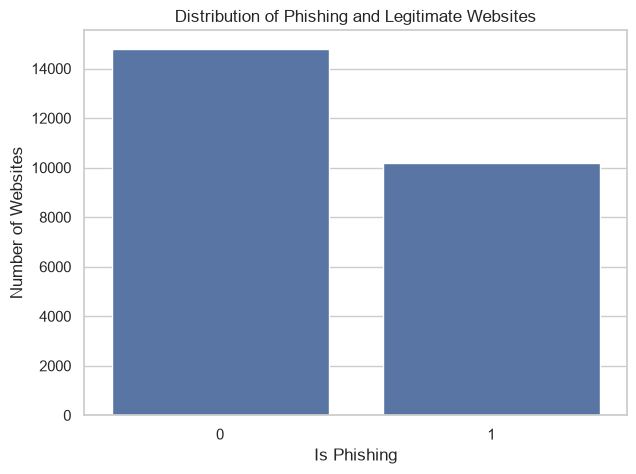

In [42]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Is_Phishing")
plt.title("Distribution of Phishing and Legitimate Websites")
plt.xlabel("Is Phishing")
plt.ylabel("Number of Websites")
plt.show()

**Distribution of EVERY Numerical Feature**

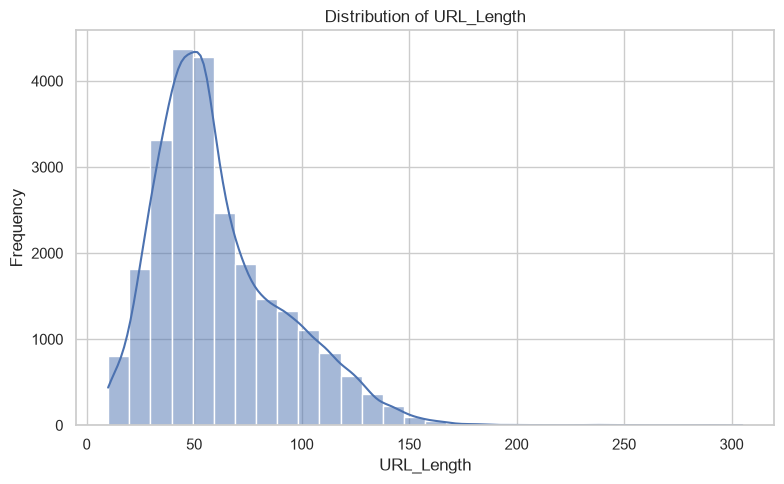

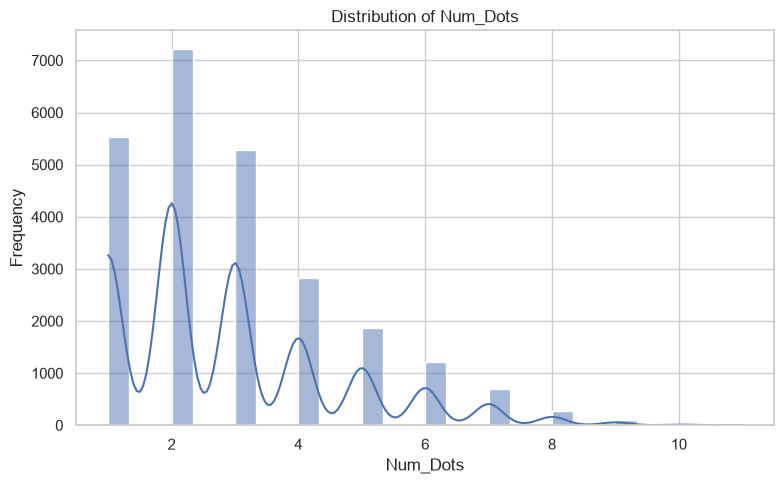

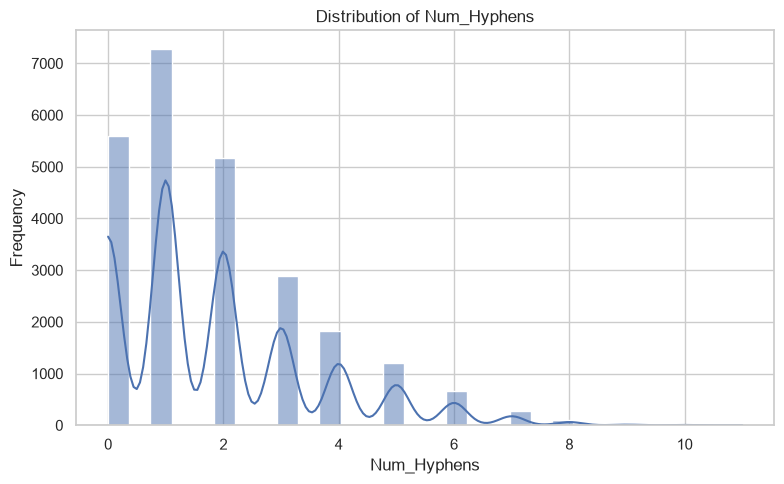

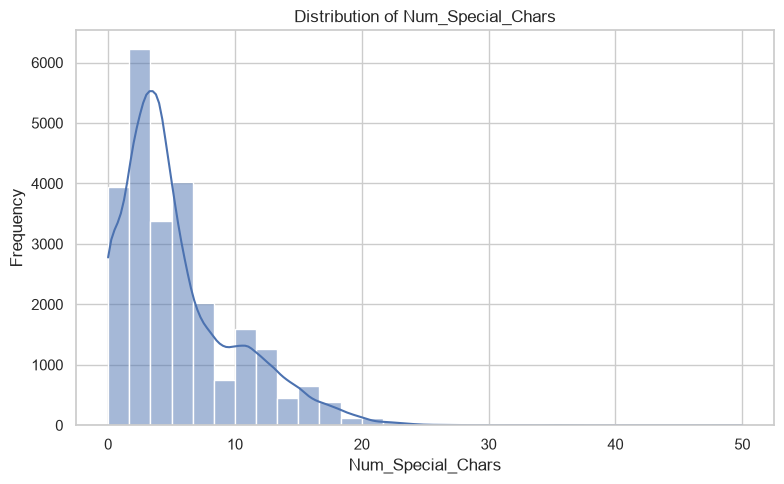

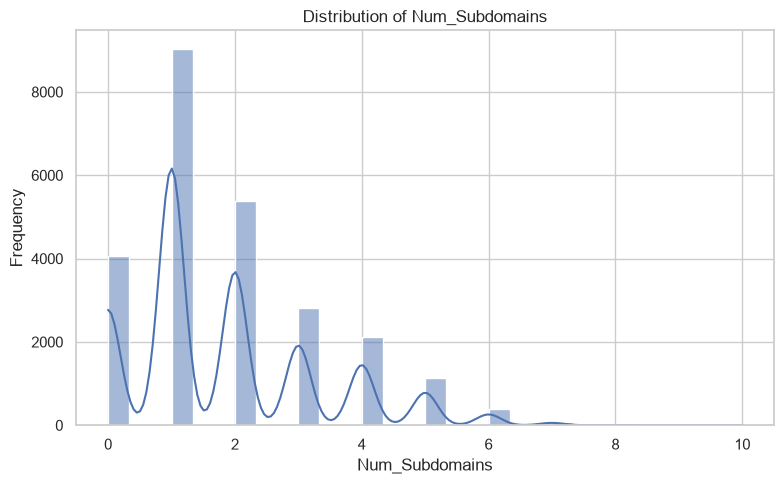

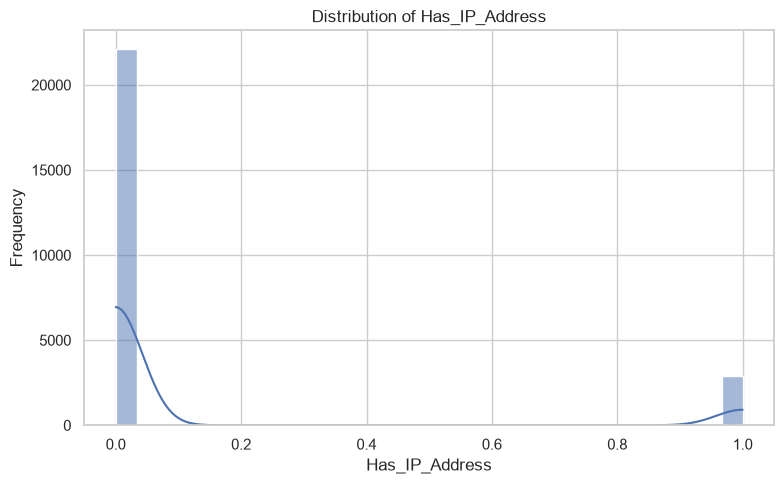

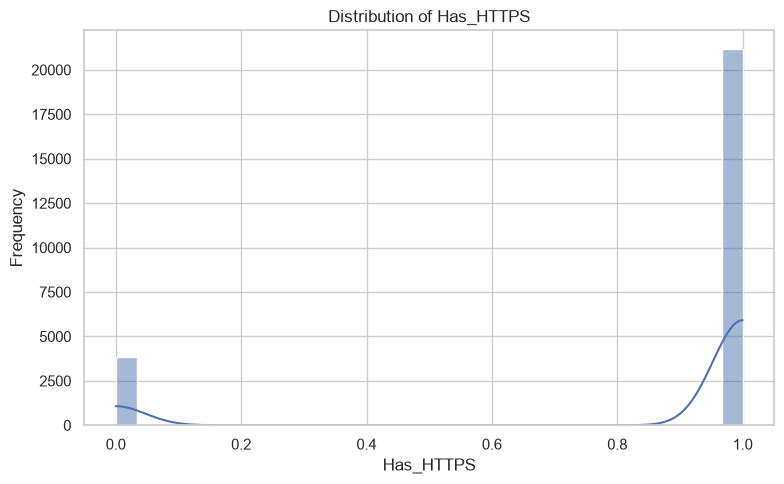

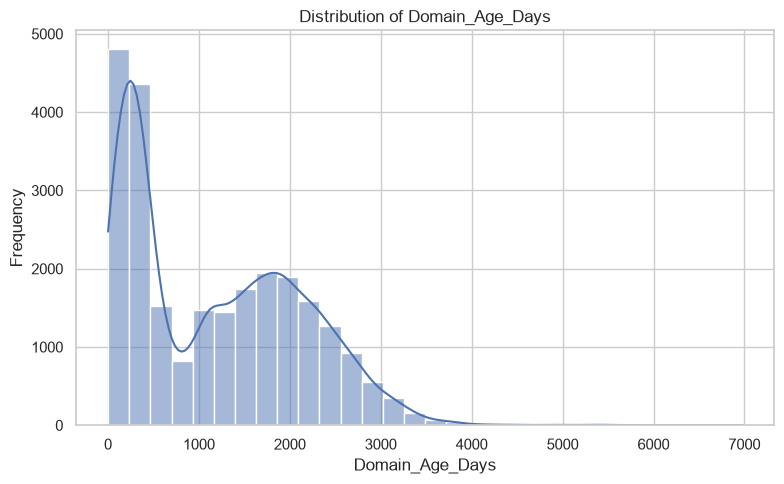

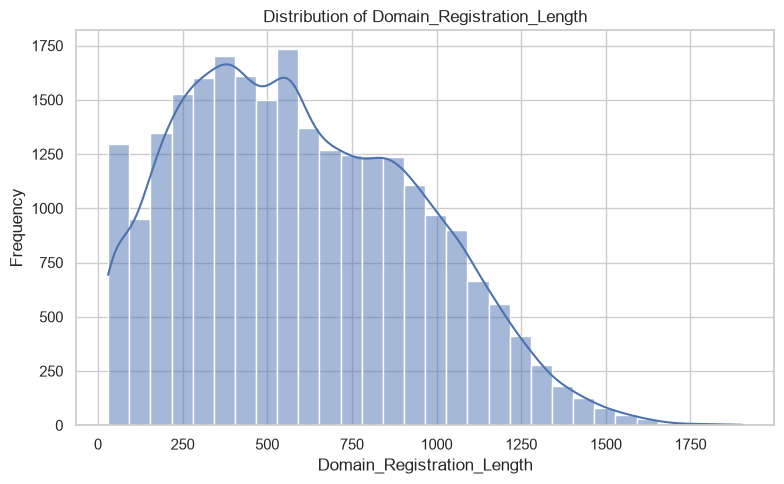

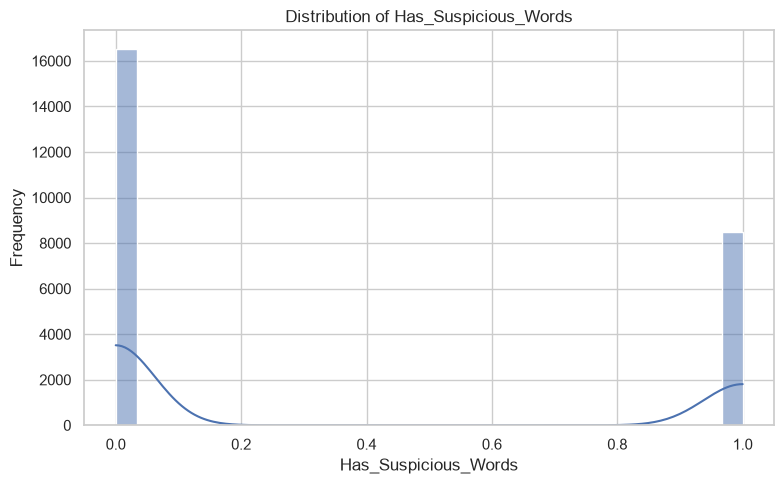

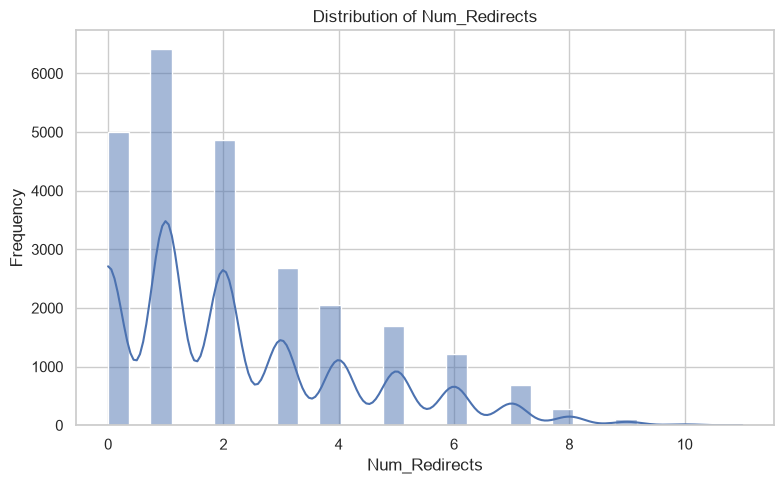

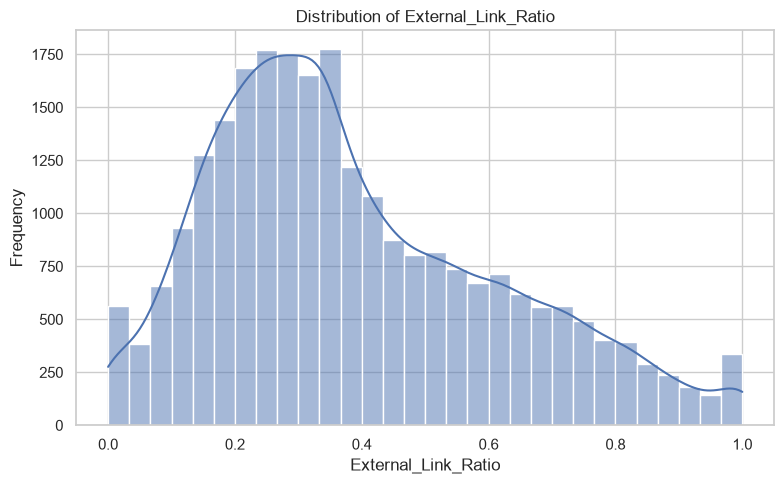

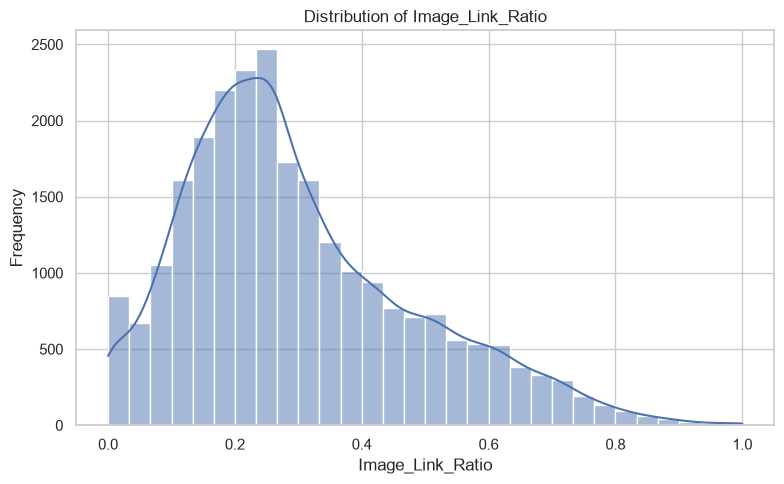

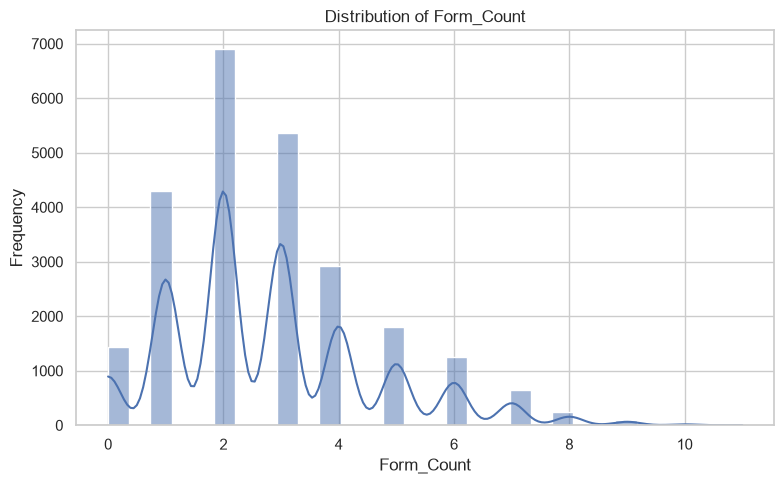

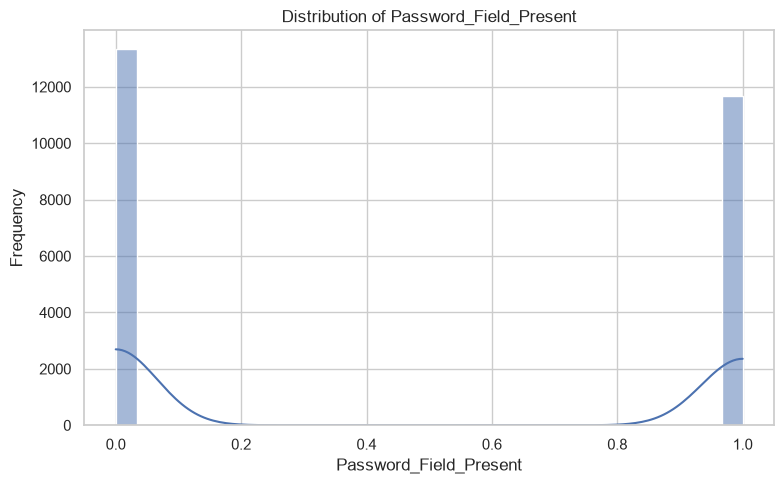

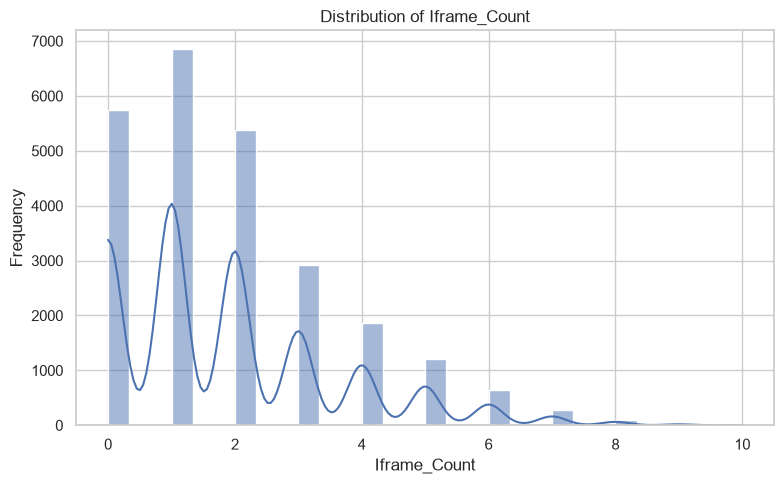

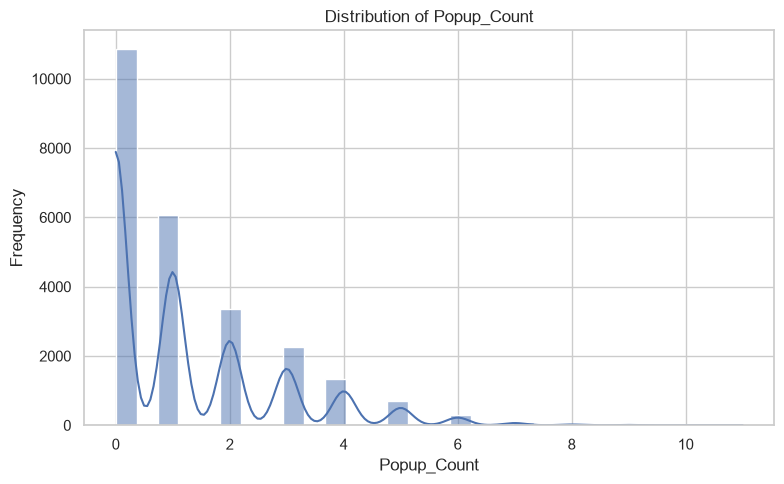

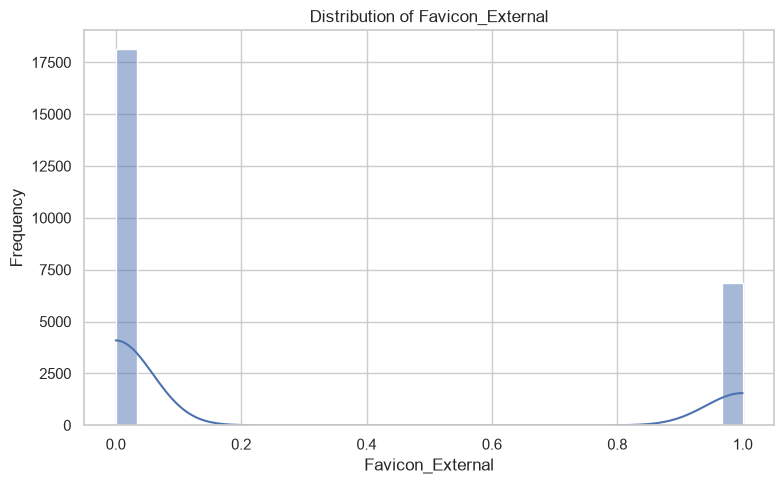

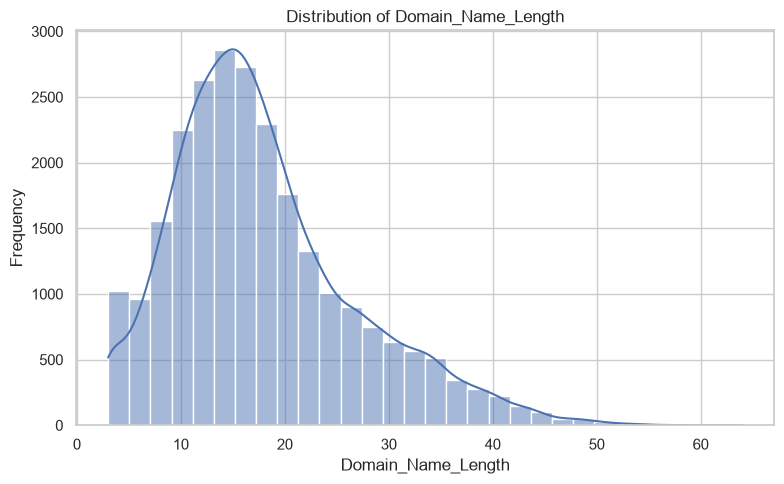

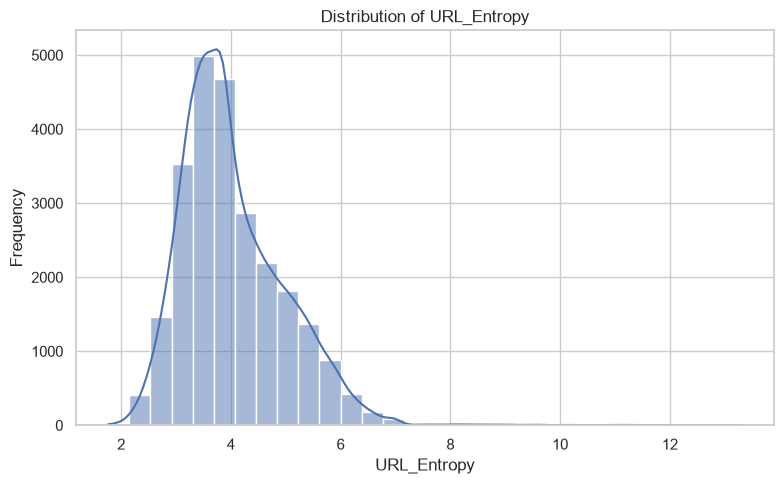

In [43]:
# Select all feature columns except target
features = df.columns.drop("Is_Phishing")
# Plot distribution of each feature
for col in features:
    plt.figure(figsize=(8, 5))
    sns.histplot(
        df[col],
        bins=30,
        kde=True)#kde=True adds a kernel density estimate to the histogram, which provides a smoothed curve representing the distribution of the data.
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()
    plt.close()

**Boxplots-Detect Outliers**

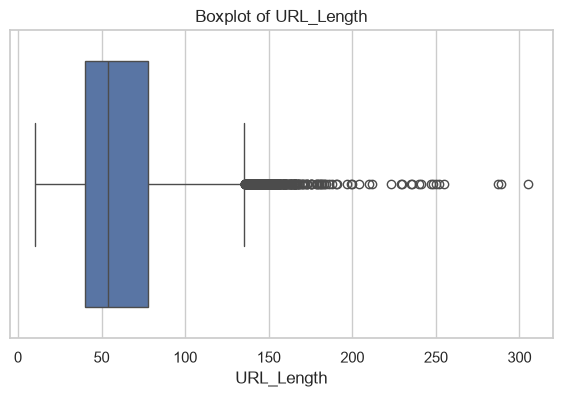

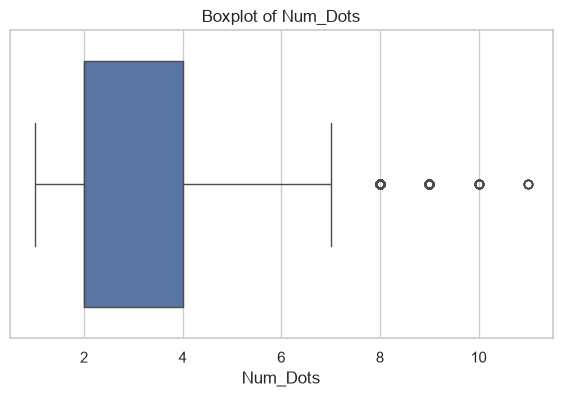

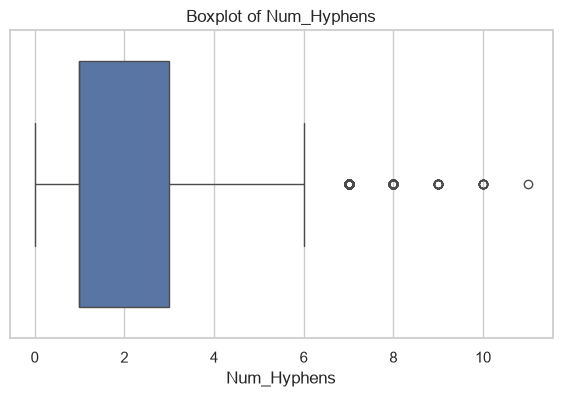

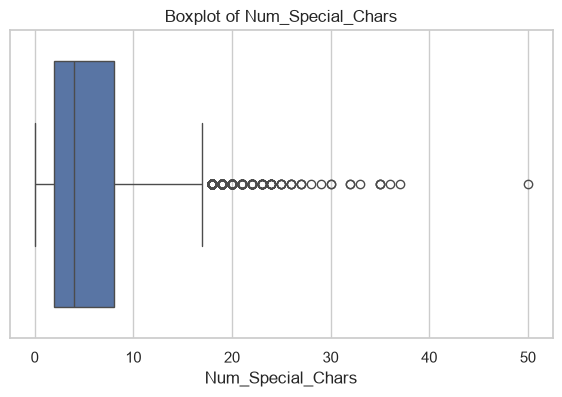

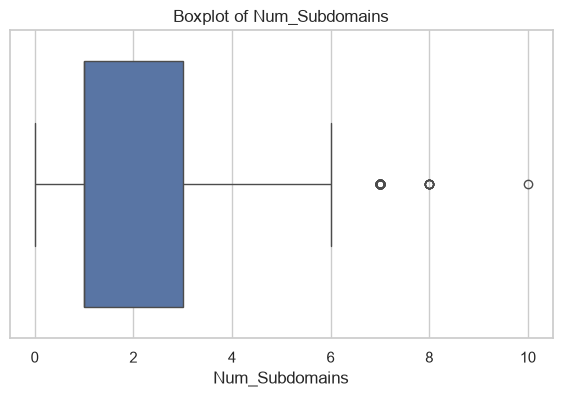

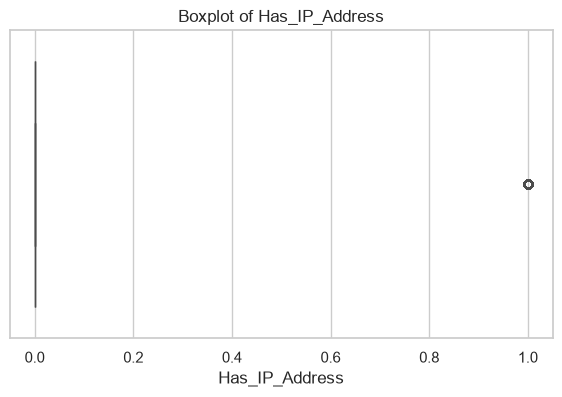

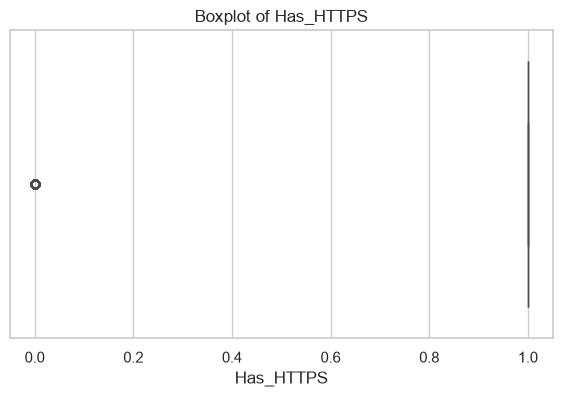

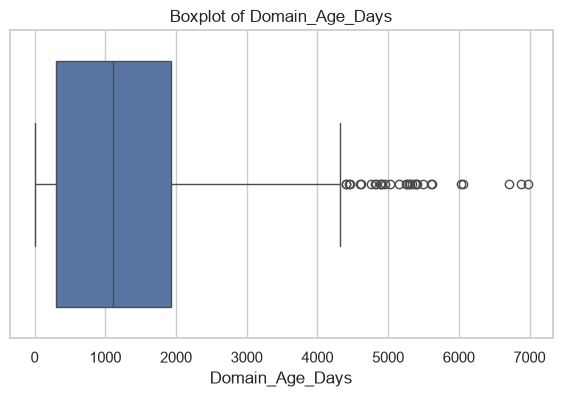

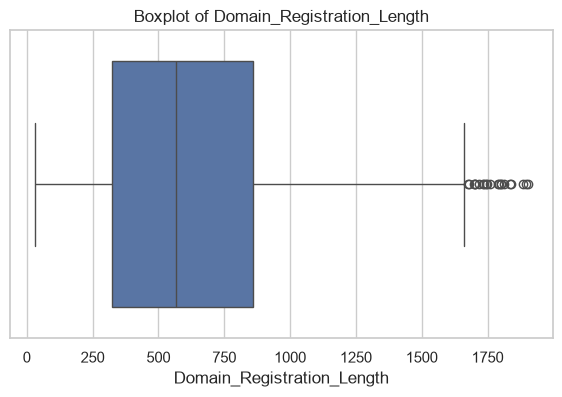

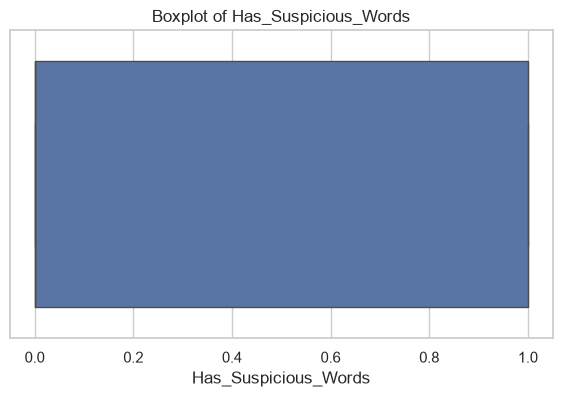

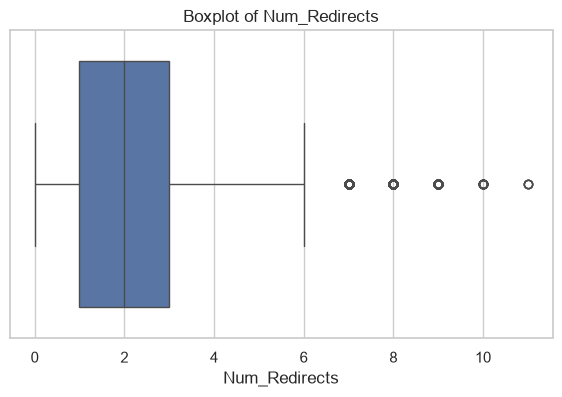

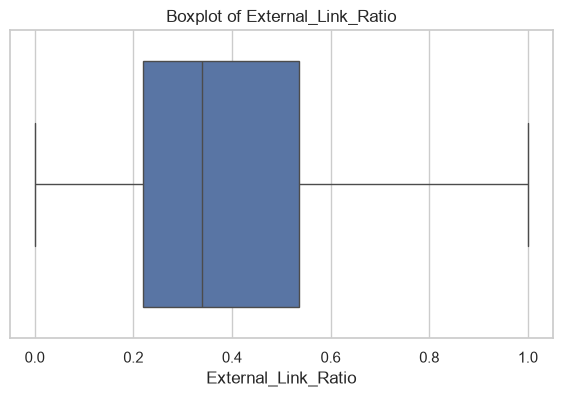

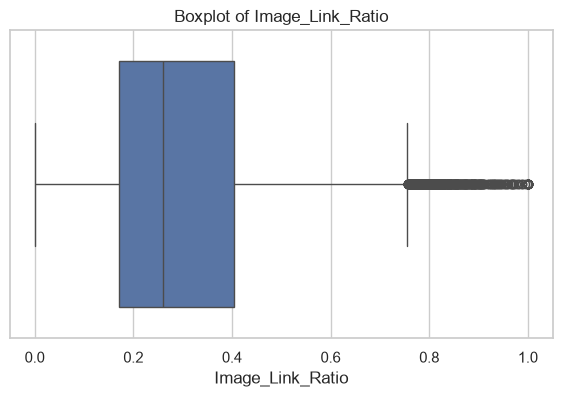

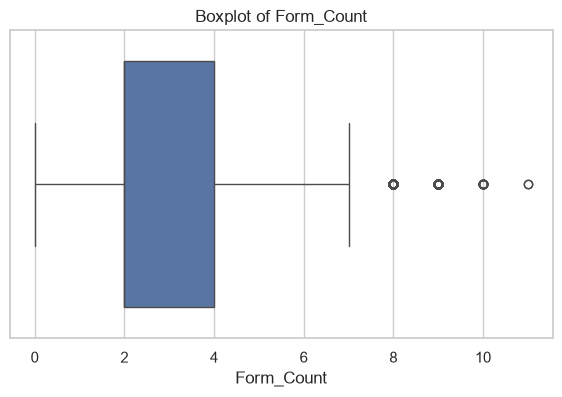

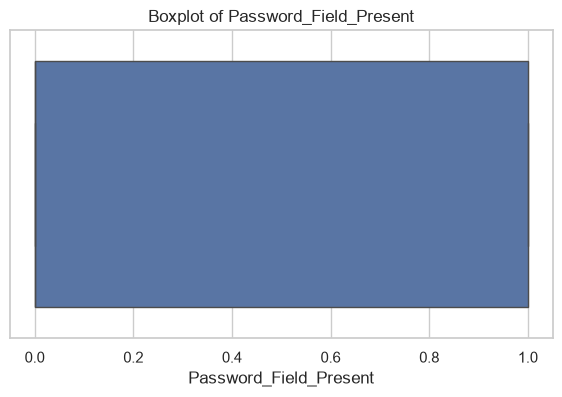

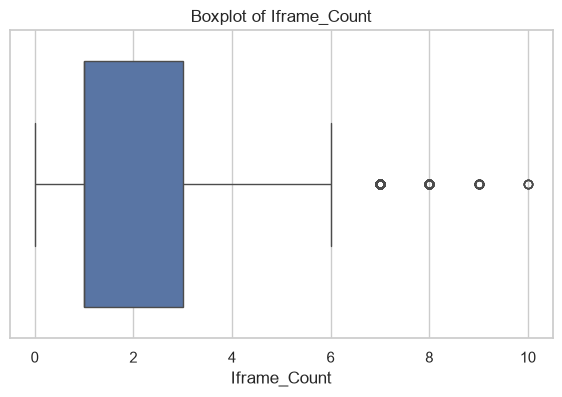

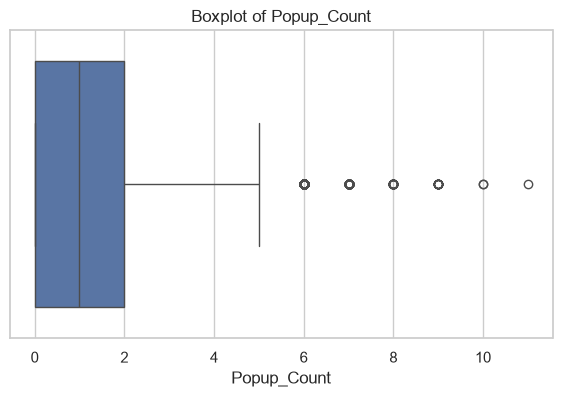

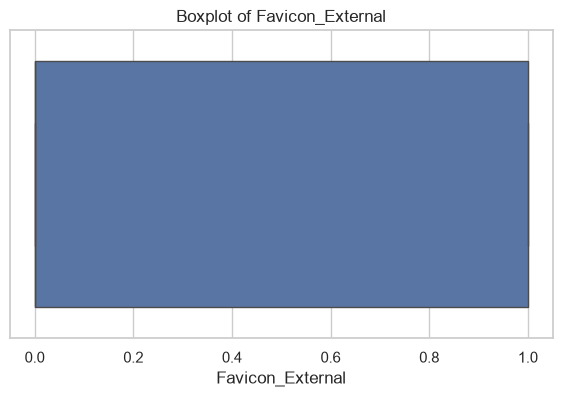

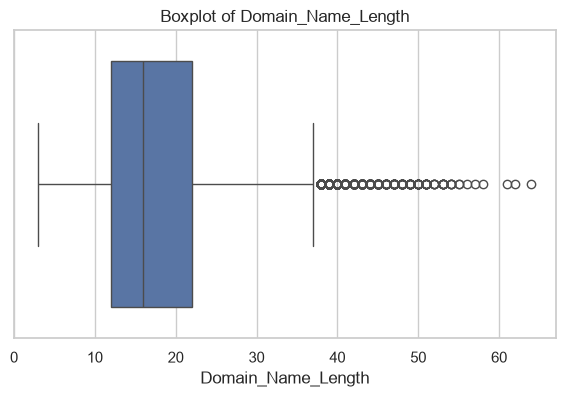

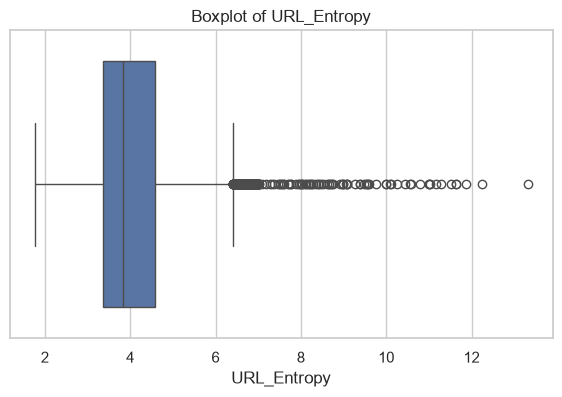

In [44]:
for col in features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

**Correlation Between Every Column**

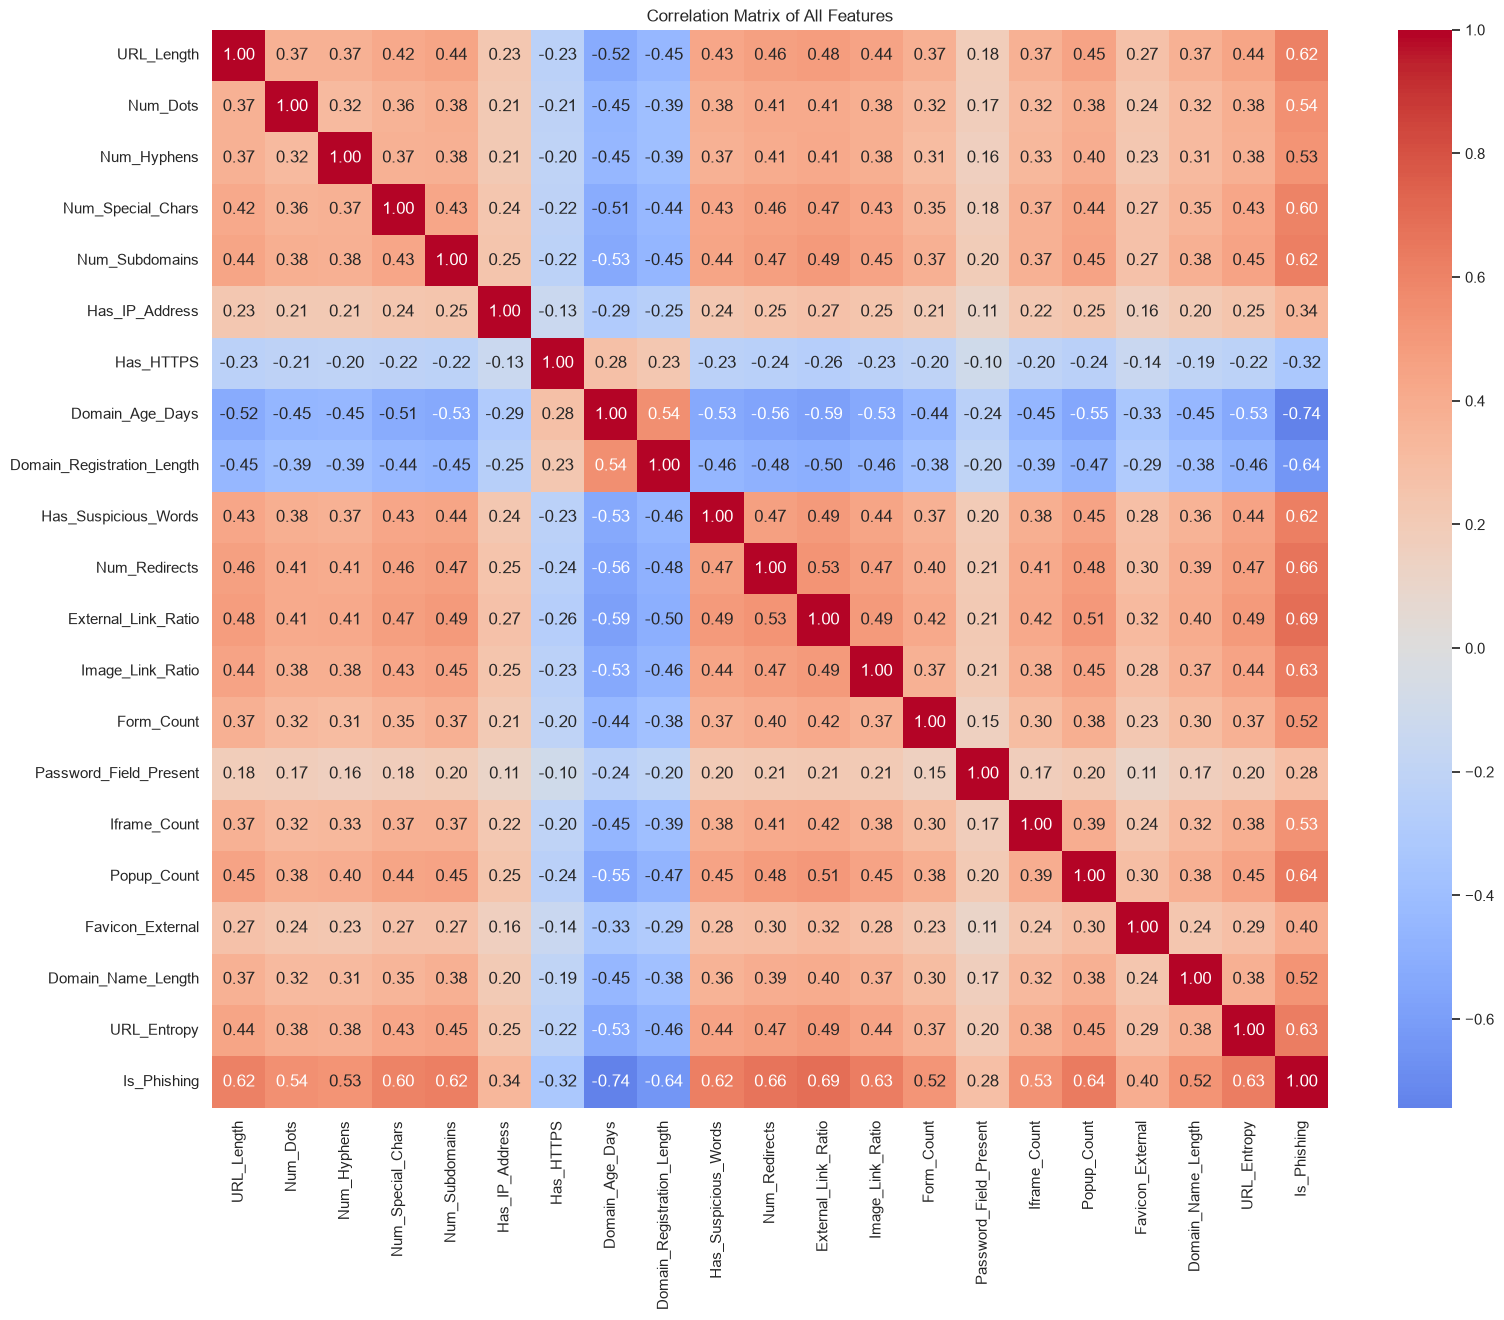

In [45]:
correlation_matrix = df.corr()
plt.figure(figsize=(18, 14))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0)
plt.title("Correlation Matrix of All Features")
plt.show()

**Relationship with Target**

In [46]:
target_corr = df.corr()["Is_Phishing"].sort_values(ascending=False)
target_corr
#It shows which feature has strongest linear relatioship with target variable(phishing)

Is_Phishing                   1.000000
External_Link_Ratio           0.690713
Num_Redirects                 0.663041
Popup_Count                   0.639044
URL_Entropy                   0.629206
Image_Link_Ratio              0.628915
Has_Suspicious_Words          0.623255
Num_Subdomains                0.620731
URL_Length                    0.615393
Num_Special_Chars             0.603787
Num_Dots                      0.540219
Iframe_Count                  0.534783
Num_Hyphens                   0.527462
Domain_Name_Length            0.523959
Form_Count                    0.522777
Favicon_External              0.396613
Has_IP_Address                0.344988
Password_Field_Present        0.279365
Has_HTTPS                    -0.322415
Domain_Registration_Length   -0.644113
Domain_Age_Days              -0.743429
Name: Is_Phishing, dtype: float64

**Plot Feature vs Target Correlation**

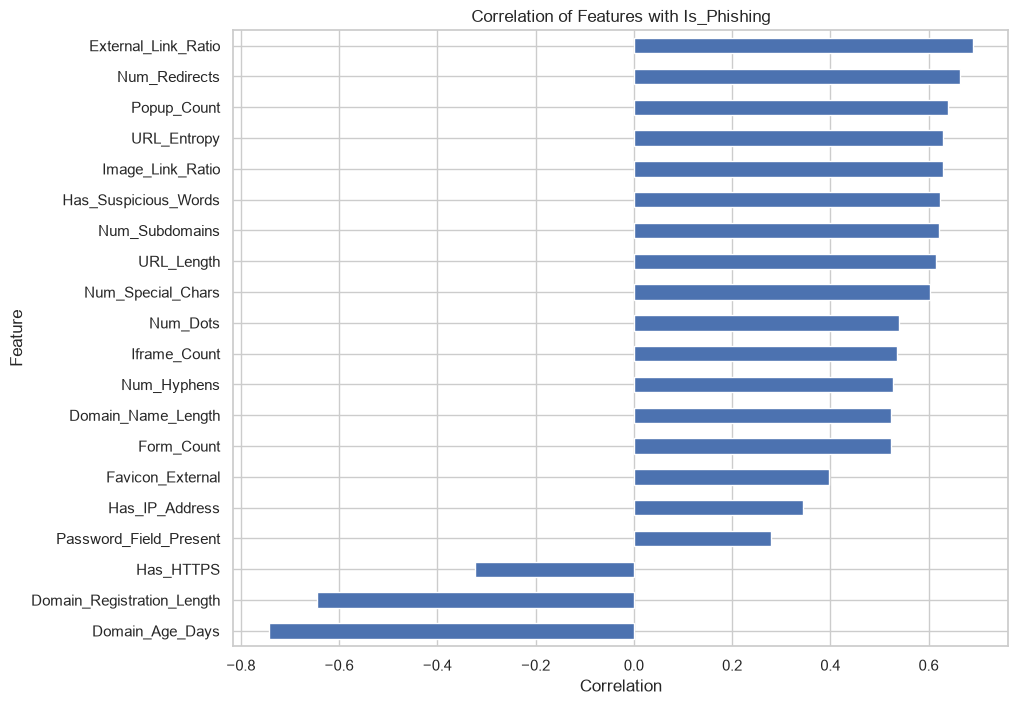

In [47]:
plt.figure(figsize=(10, 8))
target_corr.drop("Is_Phishing").sort_values().plot(kind="barh")
plt.title("Correlation of Features with Is_Phishing")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.show()
#graph shows the correlation of each feature with the target variable "Is_Phishing". Features with positive correlation values are positively associated with phishing websites, while those with negative values are negatively associated.

**Phishing vs Legitimate — Compare Every Feature**

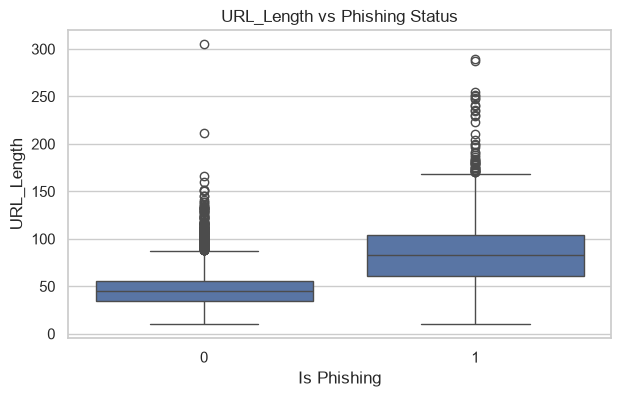

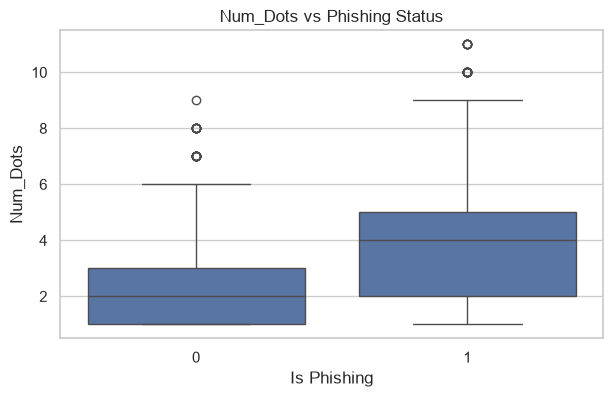

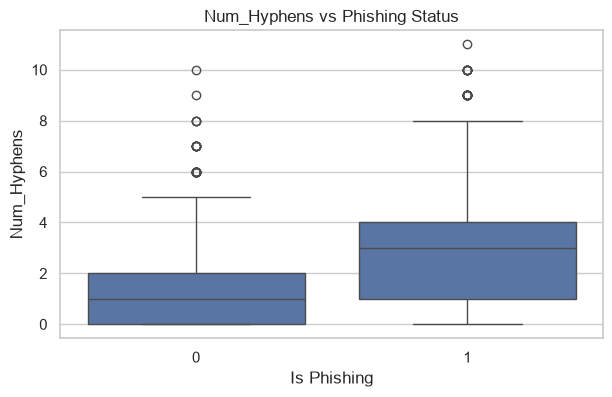

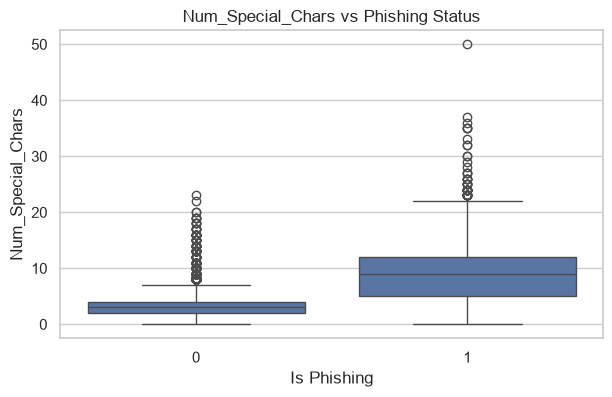

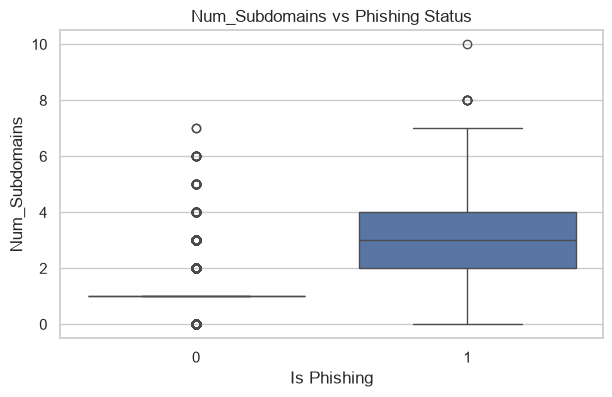

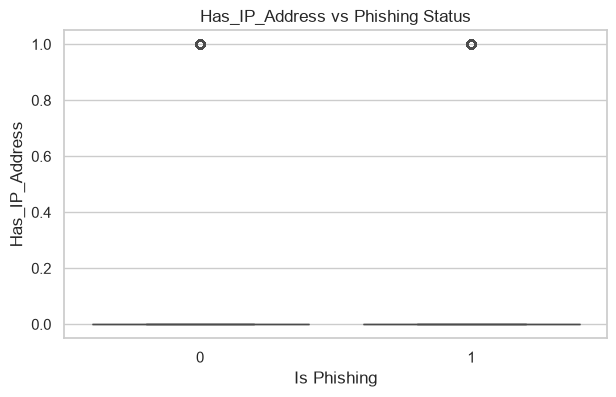

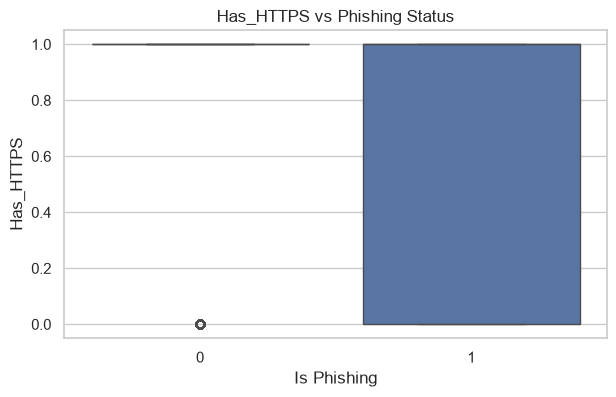

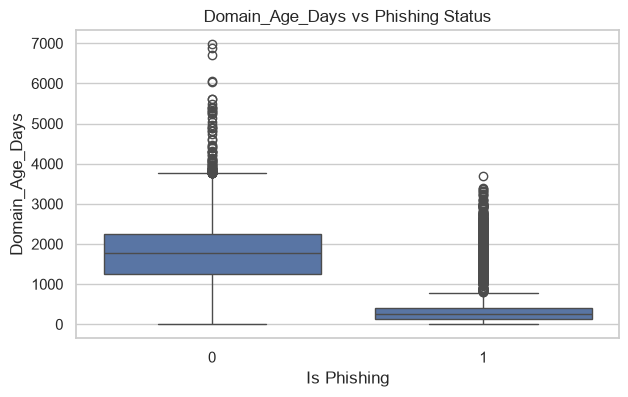

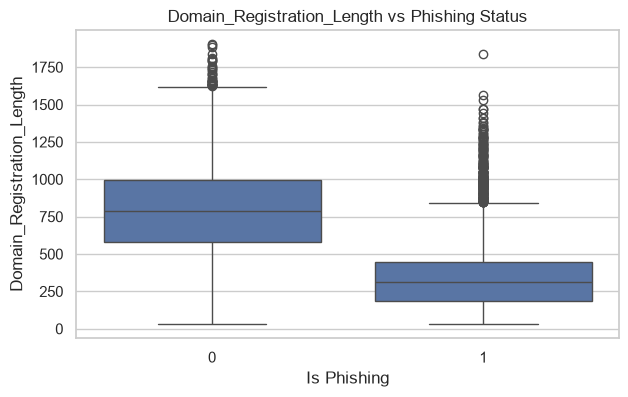

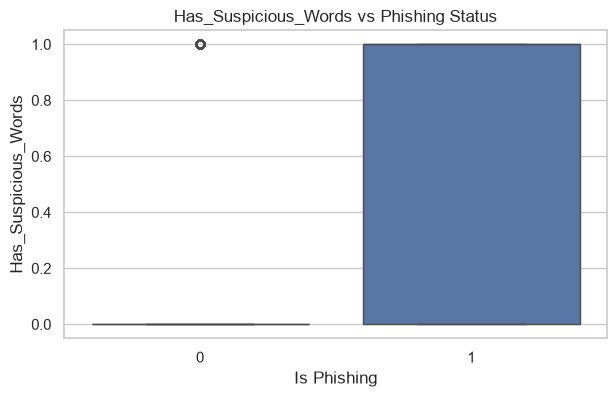

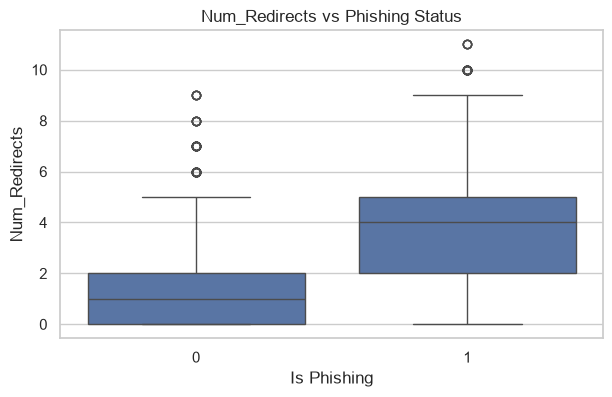

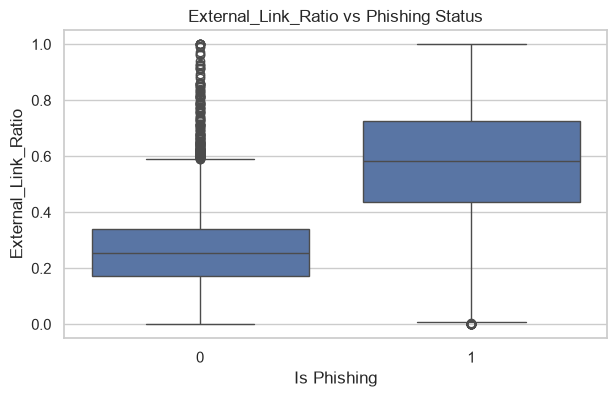

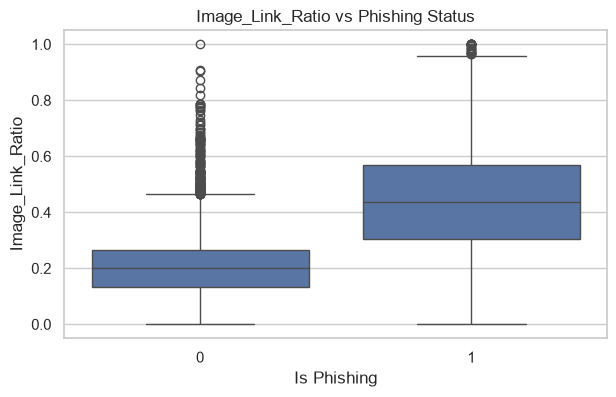

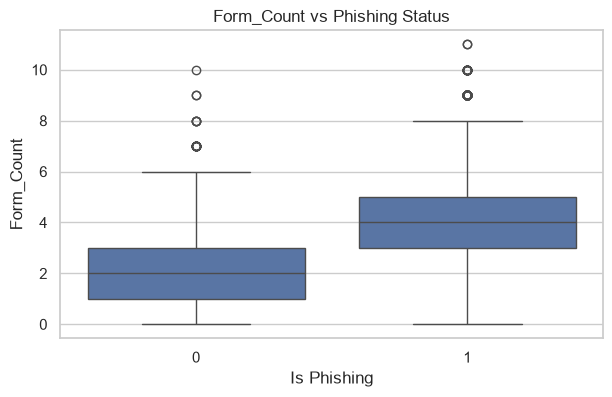

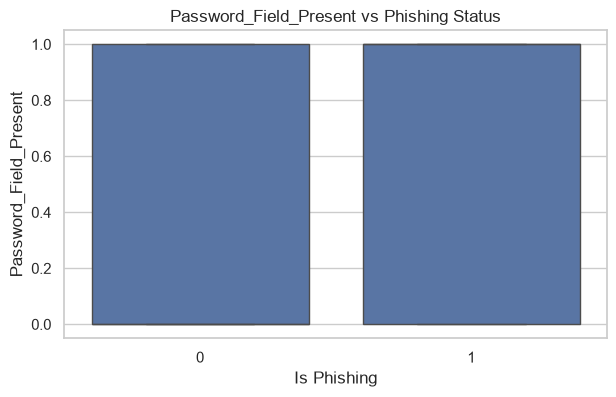

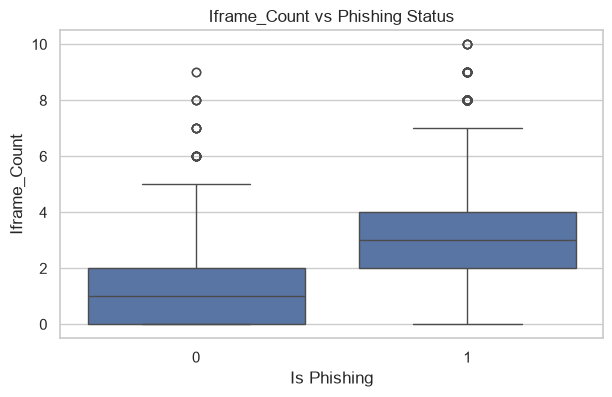

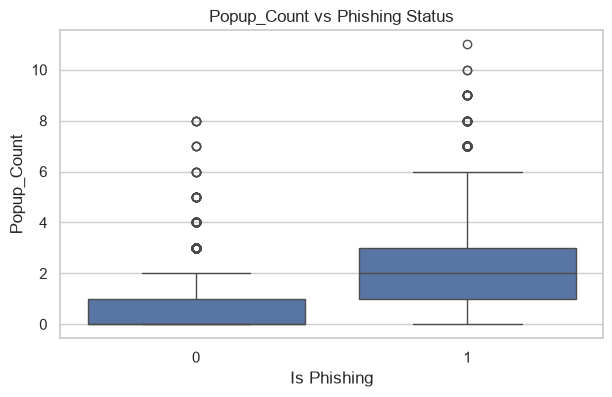

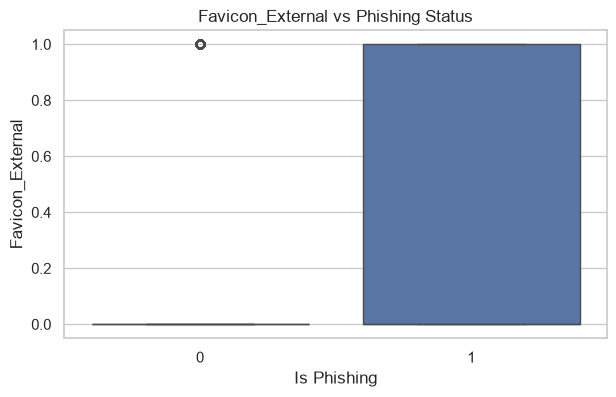

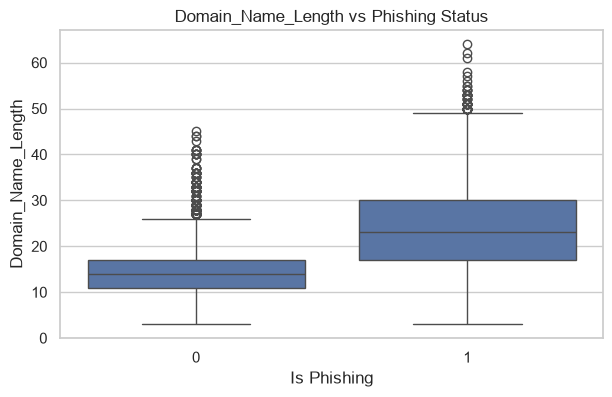

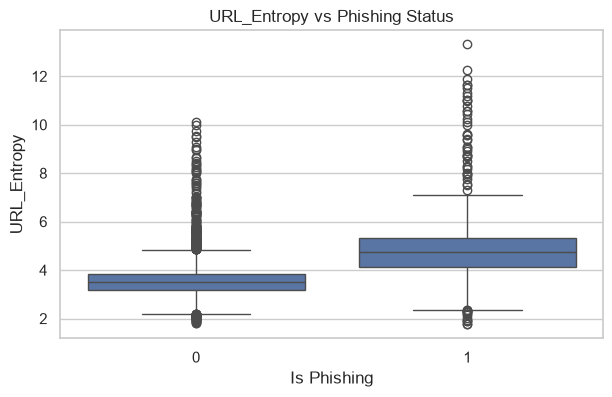

In [48]:
#Are phishing websites different from legitimate websites for each feature?
for col in features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(
        data=df,
        x="Is_Phishing",
        y=col)
    plt.title(f"{col} vs Phishing Status")
    plt.xlabel("Is Phishing")
    plt.ylabel(col)
    plt.show()

**Compare Means**

In [49]:
mean_comparison = df.groupby("Is_Phishing")[features].mean().T
mean_comparison
#comparing avg value of every feature for phishing and legitimate websites. This can help identify which features are more prominent in phishing websites compared to legitimate ones.

Is_Phishing,0,1
URL_Length,45.968526,83.493722
Num_Dots,2.107524,3.983422
Num_Hyphens,1.112184,2.938788
Num_Special_Chars,3.206808,8.799294
Num_Subdomains,1.053019,2.916716
Has_IP_Address,0.024517,0.249559
Has_HTTPS,0.942861,0.706298
Domain_Age_Days,1765.890720,340.311850
Domain_Registration_Length,787.955829,332.501471
Has_Suspicious_Words,0.094624,0.695213


**Percentage Difference**

In [51]:
#how much the phishing average differs from the legitimate average
comparison = df.groupby("Is_Phishing")[features].mean().T
comparison["Difference"] = (
    comparison[1] - comparison[0])
comparison["Percentage_Difference"] = (
    comparison["Difference"] /
    comparison[0].replace(0, np.nan)) * 100
comparison.sort_values(
    "Percentage_Difference",
    ascending=False)

Is_Phishing,0,1,Difference,Percentage_Difference
Has_IP_Address,0.024517,0.249559,0.225041,917.896445
Has_Suspicious_Words,0.094624,0.695213,0.600589,634.712474
Popup_Count,0.438403,2.421032,1.982629,452.238476
Favicon_External,0.127921,0.488228,0.360307,281.663635
Num_Redirects,1.129475,3.888464,2.758989,244.271931
Num_Subdomains,1.053019,2.916716,1.863697,176.986036
Num_Special_Chars,3.206808,8.799294,5.592486,174.394150
Iframe_Count,1.109888,2.971846,1.861958,167.760936
Num_Hyphens,1.112184,2.938788,1.826603,164.235672
External_Link_Ratio,0.258298,0.578258,0.319960,123.872236


**Binary Features**

In [52]:
binary_cols = [
    "Has_IP_Address",
    "Has_HTTPS",
    "Has_Suspicious_Words",
    "Password_Field_Present",
    "Favicon_External"]

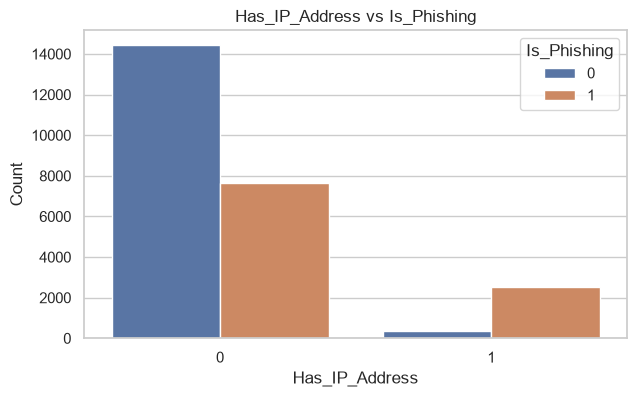

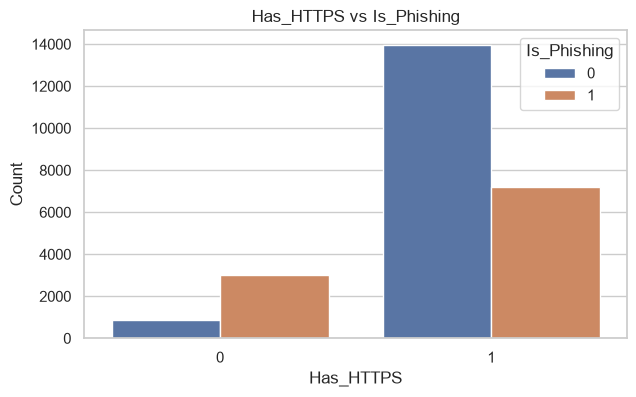

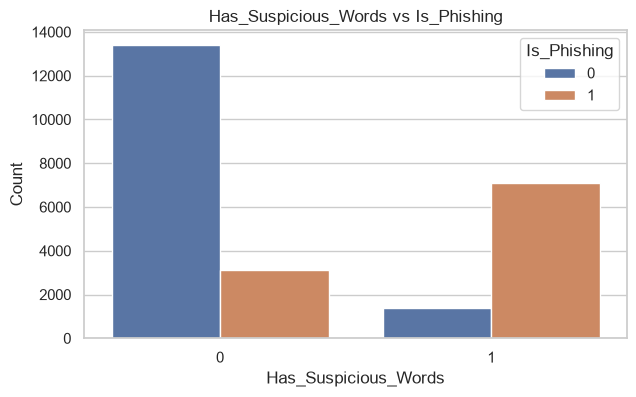

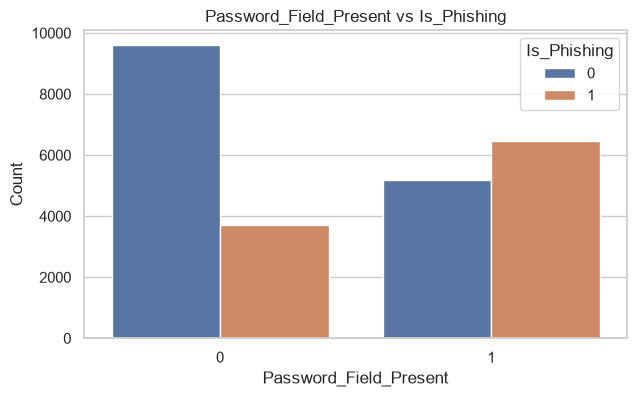

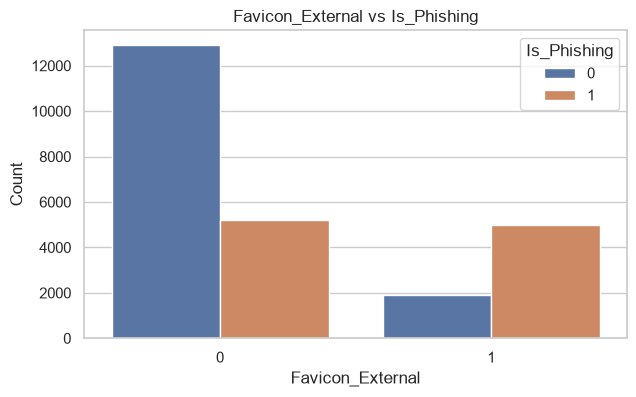

In [53]:
for col in binary_cols:
    plt.figure(figsize=(7, 4))
    sns.countplot(
        data=df,
        x=col,
        hue="Is_Phishing")
    plt.title(f"{col} vs Is_Phishing")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

**Calculate Percentages for Binary Features**

Graph shows counts, but percentages are easier to interpret

In [54]:
for col in binary_cols:
    percentage = pd.crosstab(
        df[col],
        df["Is_Phishing"],
        normalize="columns") * 100
    print("\n", col)
    print(percentage)


 Has_IP_Address
Is_Phishing             0          1
Has_IP_Address                      
0               97.548291  75.044144
1                2.451709  24.955856

 Has_HTTPS
Is_Phishing        0          1
Has_HTTPS                      
0             5.7139  29.370218
1            94.2861  70.629782

 Has_Suspicious_Words
Is_Phishing                  0          1
Has_Suspicious_Words                     
0                     90.53762  30.478713
1                      9.46238  69.521287

 Password_Field_Present
Is_Phishing                     0          1
Password_Field_Present                      
0                       64.892611  36.531293
1                       35.107389  63.468707

 Favicon_External
Is_Phishing               0          1
Favicon_External                      
0                 87.207889  51.177163
1                 12.792111  48.822837


**Scatter Plots**

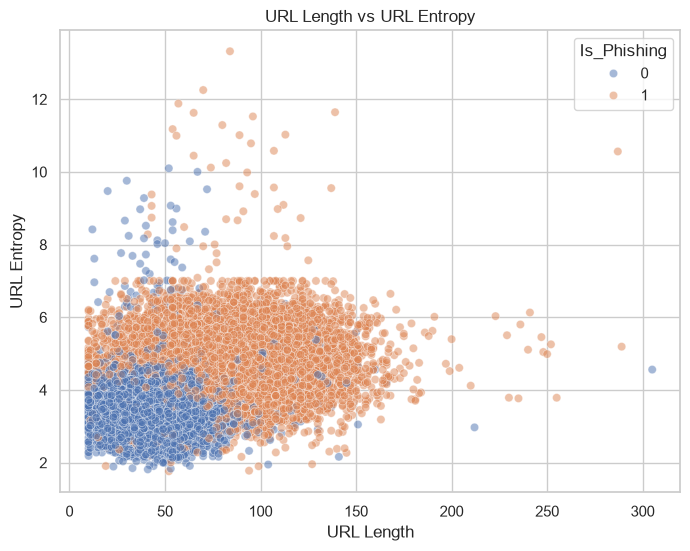

In [55]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="URL_Length",
    y="URL_Entropy",
    hue="Is_Phishing",
    alpha=0.5)
plt.title("URL Length vs URL Entropy")
plt.xlabel("URL Length")
plt.ylabel("URL Entropy")
plt.show()

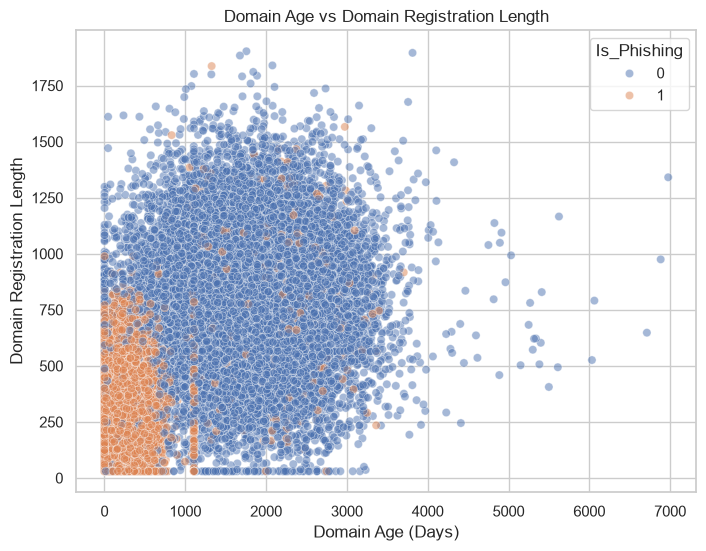

In [56]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="Domain_Age_Days",
    y="Domain_Registration_Length",
    hue="Is_Phishing",
    alpha=0.5)
plt.title("Domain Age vs Domain Registration Length")
plt.xlabel("Domain Age (Days)")
plt.ylabel("Domain Registration Length")
plt.show()

**Pairplot**

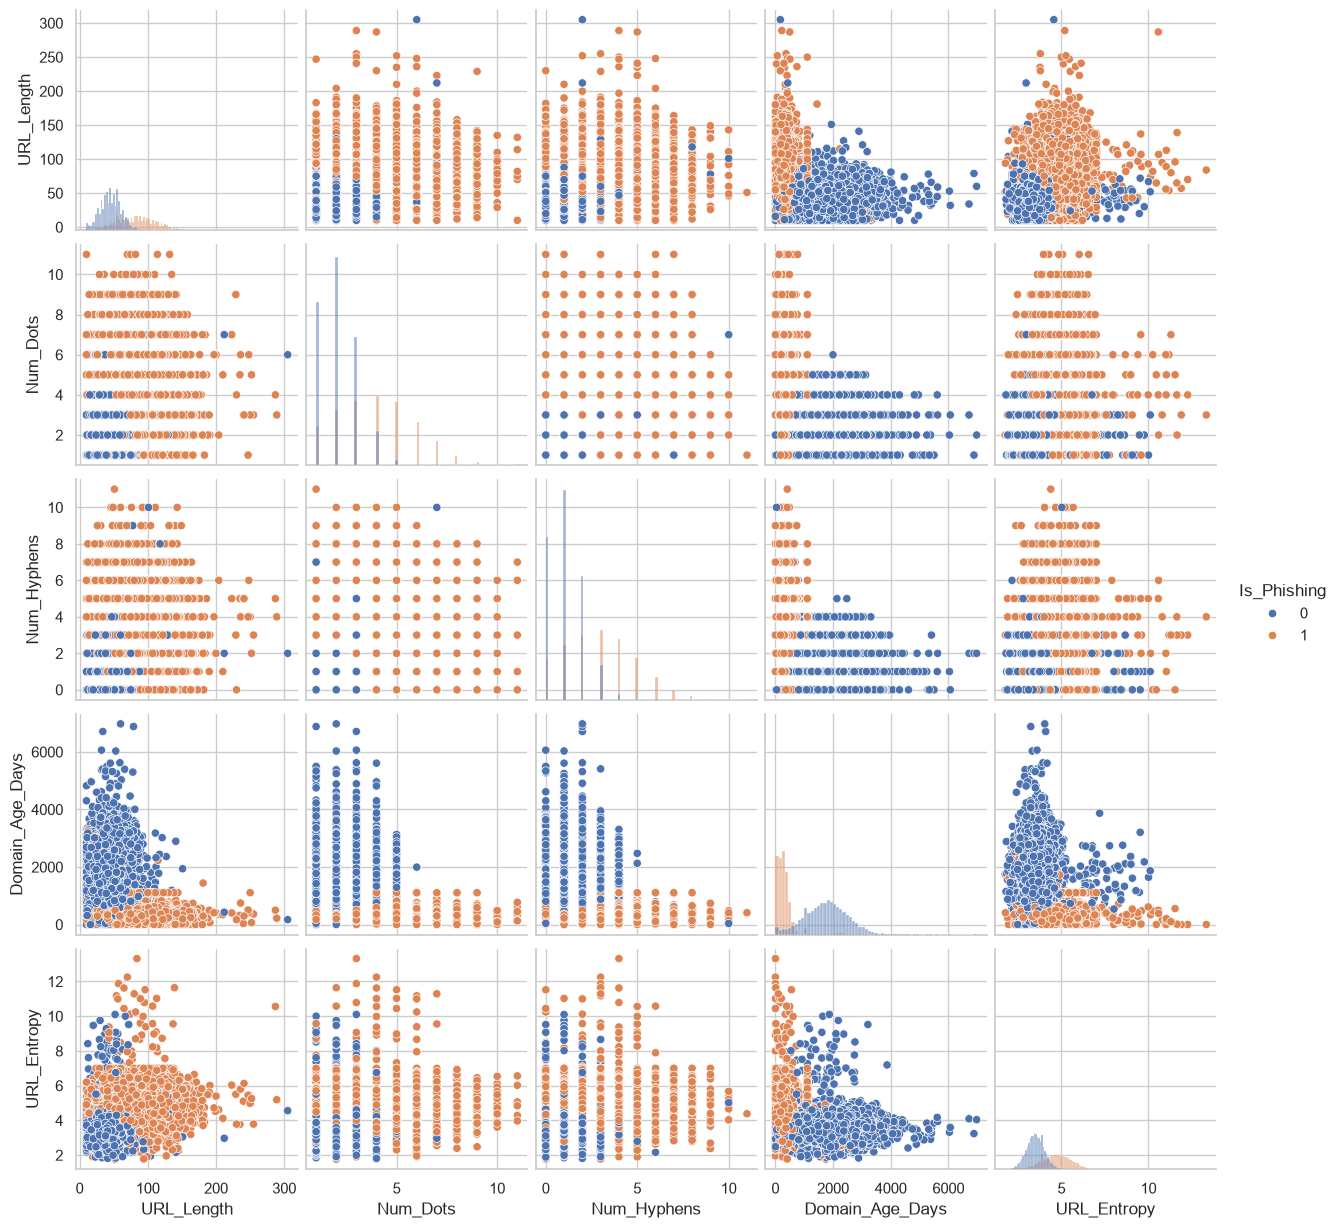

In [57]:
important_features = [
    "URL_Length",
    "Num_Dots",
    "Num_Hyphens",
    "Domain_Age_Days",
    "URL_Entropy",
    "Is_Phishing"]
sns.pairplot(
    df[important_features],
    hue="Is_Phishing",
    diag_kind="hist")
plt.show()

**Find Highly Correlated Features**

In [58]:
corr = df.drop(columns="Is_Phishing").corr()
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i):
        value = corr.iloc[i, j]
        if abs(value) >= 0.70:  
            high_corr.append(
                (corr.columns[i],
                    corr.columns[j],
                    value))
high_corr

[]

**EDA Summary**

In [59]:
eda_summary = pd.DataFrame(index=features)
eda_summary["Mean"] = df[features].mean()
eda_summary["Median"] = df[features].median()
eda_summary["Std"] = df[features].std()
eda_summary["Min"] = df[features].min()
eda_summary["Max"] = df[features].max()
eda_summary["Target_Correlation"] = df[features].corrwith(
    df["Is_Phishing"])
eda_summary = eda_summary.sort_values(
    "Target_Correlation",
    ascending=False)
eda_summary

,Mean,Median,Std,Min,Max,Target_Correlation
External_Link_Ratio,0.388765,0.339,0.227645,0.000,1.000000,0.690713
Num_Redirects,2.254480,2.000,2.044888,0.000,11.000000,0.663041
Popup_Count,1.246840,1.000,1.524652,0.000,11.000000,0.639044
URL_Entropy,4.032438,3.843,0.944225,1.762,13.319632,0.629206
Image_Link_Ratio,0.300252,0.260,0.183608,0.000,1.000000,0.628915
Has_Suspicious_Words,0.339520,0.000,0.473556,0.000,1.000000,0.623255
Num_Subdomains,1.812960,1.000,1.475474,0.000,10.000000,0.620731
URL_Length,61.269800,54.000,29.966119,10.000,305.000000,0.615393
Num_Special_Chars,5.487200,4.000,4.551776,0.000,50.000000,0.603787
Num_Dots,2.872440,2.000,1.706471,1.000,11.000000,0.540219


**Define X and Y**

In [60]:
X = df.drop("Is_Phishing", axis=1)
y = df["Is_Phishing"]

In [61]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (25000, 20)
y shape: (25000,)


**Test/Train Split**

We also use stratify=y so the proportion of phishing/legitimate websites remains similar in both datasets.

In [62]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y)

In [63]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (20000, 20)
Testing data: (5000, 20)


In [64]:
#check target distributions
print("Training target distribution:")
print(y_train.value_counts())
print("\nTesting target distribution:")
print(y_test.value_counts())

Training target distribution:
Is_Phishing
0    11845
1     8155
Name: count, dtype: int64

Testing target distribution:
Is_Phishing
0    2961
1    2039
Name: count, dtype: int64


**Preprocessing/Scaling**

In [65]:
#will ue StandardScaslar
from sklearn.preprocessing import StandardScaler

In [66]:
scaler = StandardScaler()

In [67]:
#fit only traning data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [68]:
scaler.fit_transform(X_test)

array([[-0.30789357, -1.10600136,  0.07091588, ..., -0.613411  ,
        -0.11694819, -0.68778237],
       [ 0.81628829,  0.64050042,  1.24114491, ...,  1.63022835,
         1.0178101 ,  0.74047895],
       [-1.26675457, -0.5238341 ,  1.24114491, ..., -0.613411  ,
        -1.25170648, -0.41736775],
       ...,
       [-0.60547112,  0.64050042,  0.65603039, ..., -0.613411  ,
         1.58518925,  1.28774662],
       [ 0.0888765 ,  2.96916946, -0.51419863, ...,  1.63022835,
         2.1525684 ,  0.77159809],
       [-0.90304868,  0.05833316, -0.51419863, ..., -0.613411  ,
        -0.911279  , -1.05048133]], shape=(5000, 20))

**Model 1--Logistic Regression**

In [69]:
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42)
logistic_model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [70]:
#prediction
y_pred_lr = logistic_model.predict(X_test_scaled)

In [71]:
#Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report)
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))

Logistic Regression
Accuracy: 0.971
Precision: 0.9697420634920635
Recall: 0.9588033349681216
F1 Score: 0.9642416769420469


**Model 2--Decision Tree**

In [72]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(
    random_state=42)
dt_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [73]:
#Prediction
y_pred_dt = dt_model.predict(X_test)

In [74]:
#Evaluation
print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))

Decision Tree
Accuracy: 0.9224
Precision: 0.9013125911521633
Recall: 0.9092692496321726
F1 Score: 0.9052734375


**Model 3--Random Forest**

In [75]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1)
rf_model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [76]:
#Prediction
y_pred_rf = rf_model.predict(X_test)

In [77]:
#Evaluation
print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

Random Forest
Accuracy: 0.9712
Precision: 0.9692917285785042
Recall: 0.9597842079450711
F1 Score: 0.964514539181863


**Model Comparision**

In [78]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)]})
results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9710,0.969742,0.958803,0.964242
1,Decision Tree,0.9224,0.901313,0.909269,0.905273
2,Random Forest,0.9712,0.969292,0.959784,0.964515


**Best Model**

In [79]:
best_model_name = results.loc[
    results["F1 Score"].idxmax(),
    "Model"]
best_f1 = results["F1 Score"].max()
print("Best Model:", best_model_name)
print("Best F1 Score:", best_f1)

Best Model: Random Forest
Best F1 Score: 0.964514539181863


**HyperParameter Tuning**

In [80]:
from sklearn.model_selection import GridSearchCV

In [81]:
if best_model_name == "Logistic Regression":
    param_grid = {
        "C": [0.01, 0.1, 1, 10, 100],
        "solver": ["liblinear", "lbfgs"]}
    tuning_model = LogisticRegression(
        max_iter=1000,
        random_state=42)
    grid_search = GridSearchCV(
        tuning_model,
        param_grid,
        cv=5,
        scoring="f1",
        n_jobs=-1)
    grid_search.fit(X_train_scaled, y_train)
elif best_model_name == "Decision Tree":
    param_grid = {
        "max_depth": [3, 5, 10, 15, 20, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "criterion": ["gini", "entropy"]}
    tuning_model = DecisionTreeClassifier(
        random_state=42)
    grid_search = GridSearchCV(
        tuning_model,
        param_grid,
        cv=5,
        scoring="f1",
        n_jobs=-1)
    grid_search.fit(X_train, y_train)
else:
    param_grid = {
        "n_estimators": [100, 200],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2]}
    tuning_model = RandomForestClassifier(
        random_state=42,
        n_jobs=-1)
    grid_search = GridSearchCV(
        tuning_model,
        param_grid,
        cv=5,
        scoring="f1",
        n_jobs=-1)
    grid_search.fit(X_train, y_train)

**Check Best Parameter**

In [82]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


In [83]:
print("Best Cross-Validation F1 Score:")
print(grid_search.best_score_)

Best Cross-Validation F1 Score:
0.9622451732715065


**Final Evaluation**

Now evaluate the tuned model on the unseen test data

In [ ]:
best_tuned_model = grid_search.best_estimator_

In [85]:
#Prediction
if best_model_name == "Logistic Regression":
    y_pred_final = best_tuned_model.predict(X_test_scaled)
else:
    y_pred_final = best_tuned_model.predict(X_test)

In [87]:
final_accuracy = accuracy_score(y_test, y_pred_final)
final_precision = precision_score(y_test, y_pred_final)
final_recall = recall_score(y_test, y_pred_final)
final_f1 = f1_score(y_test, y_pred_final)
print("FINAL MODEL PERFORMANCE")
print("Model:", best_model_name)
print("Accuracy:", final_accuracy)
print("Precision:", final_precision)
print("Recall:", final_recall)
print("F1 Score:", final_f1)

FINAL MODEL PERFORMANCE
Model: Random Forest
Accuracy: 0.9716
Precision: 0.970252850768468
Recall: 0.9597842079450711
F1 Score: 0.9649901380670611


**Confusion Matrix**

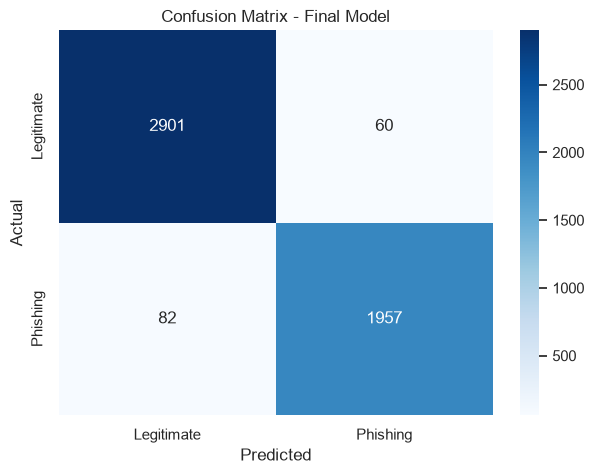

In [88]:
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Phishing"],
    yticklabels=["Legitimate", "Phishing"])
plt.title("Confusion Matrix - Final Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [89]:
print(classification_report(
    y_test,
    y_pred_final,
    target_names=["Legitimate", "Phishing"]))

              precision    recall  f1-score   support

  Legitimate       0.97      0.98      0.98      2961
    Phishing       0.97      0.96      0.96      2039

    accuracy                           0.97      5000
   macro avg       0.97      0.97      0.97      5000
weighted avg       0.97      0.97      0.97      5000



**Save Best Model**

In [90]:
import joblib

In [91]:
joblib.dump(
    best_tuned_model,
    "best_phishing_model.pkl")
if best_model_name == "Logistic Regression":
    joblib.dump(
        scaler,
        "phishing_scaler.pkl")

In [92]:
import os
print("Model saved:", os.path.exists("best_phishing_model.pkl"))
if best_model_name == "Logistic Regression":
    print("Scaler saved:", os.path.exists("phishing_scaler.pkl"))

Model saved: True


**Conclusion:**

The project successfully classified websites as phishing or legitimate using machine learning.

The dataset was cleaned, explored, and analyzed to identify important patterns.

Feature engineering was performed to improve the available information for the models.

Multiple classification models were trained, compared, and tuned to select the best model.

The final model can be used for phishing website prediction and integrated into a Streamlit application.